# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Common packages & ultility functions

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,accuracy_score, precision_score, recall_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import random

I0000 00:00:1778486785.382594   61527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778486785.421141   61527 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778486786.818505   61527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
def normalize_multifeature(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom

        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

In [5]:
def prepare_data_k(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        data_label.append(df['Open'].iloc[i + window_size + k - 1])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [6]:
def train_k(k):
    X_k, y_k = prepare_data_k(df, feature_columns, window_size, k)
    
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, shuffle=False)
    X_train_k, X_val_k, y_train_k, y_val_k = train_test_split(X_train_k, y_train_k, test_size=0.2, shuffle=False)
    
    print(f"Training set: {X_train_k.shape[0]}, Val: {X_val_k.shape[0]}, Test: {X_test_k.shape[0]}")
    
    X_train_norm_k, y_train_norm_k = normalize_multifeature(X_train_k, y_train_k)
    X_val_norm_k, y_val_norm_k = normalize_multifeature(X_val_k, y_val_k)
    X_test_norm_k, y_test_norm_k = normalize_multifeature(X_test_k, y_test_k)
    
    model_k = tf.keras.Sequential()
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
    model_k.add(MaxPooling1D(pool_size=2))
    model_k.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Flatten())
    model_k.add(Dense(100, activation='relu'))
    model_k.add(Dense(1))
    
    model_k.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    history_k = model_k.fit(X_train_norm_k, y_train_norm_k, validation_data=(X_val_norm_k, y_val_norm_k), epochs=5, batch_size=512, verbose=1)
    
    y_pred_norm_k = model_k.predict(X_test_norm_k)
    mse_k = mean_squared_error(y_pred_norm_k, y_test_norm_k)
    
    y_pred_denorm_k = y_pred_norm_k.copy()
    for i in range(len(y_pred_denorm_k)):
        open_min = np.min(X_test_k[i, :, 1])
        open_max = np.max(X_test_k[i, :, 1])
        y_pred_denorm_k[i] = y_pred_norm_k[i] * (open_max - open_min) + open_min
    
    return {
        'mse_norm': mse_k,
        'y_pred_denorm': y_pred_denorm_k,
        'y_test': y_test_k,
        'model': model_k,
        'history': history_k
    }

In [7]:
def prepare_data_multistep(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        for day in range(k):
            data_label.append(df['Open'].iloc[i + window_size + day])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [8]:
def normalize_multifeature_multi(X, y, k):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        
        for day in range(k):
            open_min = np.min(X[i, :, 1])
            open_max = np.max(X[i, :, 1])
            open_denom = open_max - open_min
            if open_denom == 0:
                y_norm[i, day] = 0
            else:
                y_norm[i, day] = (y[i, day] - open_min) / open_denom
    
    return X_norm, y_norm

## Task 1.1: Nasdaq Multi-Feature Extension

This section implements stock price prediction using multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of relying solely on the Open price. The model uses a 30-day sliding window to predict the next day's Open price.


In [21]:
data_appl = pd.read_csv('data/AAPL.csv')

In [22]:
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [23]:
data_appl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 682.7 KB


In [24]:
df = data_appl.copy()
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
num_features = len(feature_columns)

X_data = []
y_data = []
window_size = 30

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df[feature_columns].iloc[i + j].values)

    data_label.append(df['Open'].iloc[i + window_size])

    X_data.append(np.array(data_feature))
    y_data.append(np.array(data_label))

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)
print("Number of features: ", X_train.shape[2])

Shape of training set:  (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)
Number of features:  6


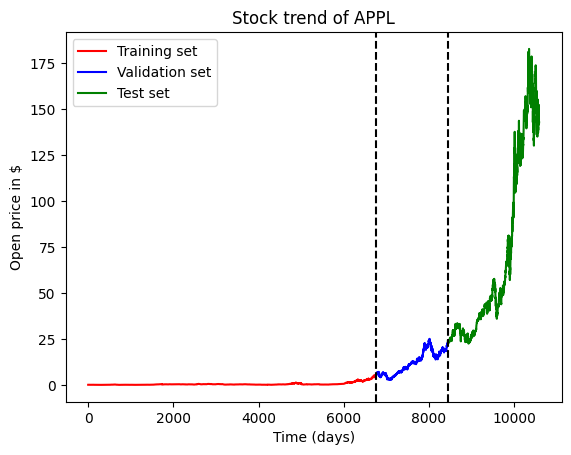

In [26]:
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [27]:
X_train_norm, y_train_norm = normalize_multifeature(X_train, y_train)
X_val_norm, y_val_norm = normalize_multifeature(X_val, y_val)

In [28]:
model = tf.keras.Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.2495 - mse: 0.2495 - val_loss: 0.0706 - val_mse: 0.0706
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0428 - mse: 0.0428 - val_loss: 0.0205 - val_mse: 0.0205
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0176 - mse: 0.0176 - val_loss: 0.0171 - val_mse: 0.0171
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145 - mse: 0.0145 - val_loss: 0.0139 - val_mse: 0.0139
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0142 - val_mse: 0.0142


In [29]:
X_test_norm, y_test_norm = normalize_multifeature(X_test, y_test)
y_pred_norm = model.predict(X_test_norm)
mse = mean_squared_error(y_pred_norm, y_test_norm)
print("MSE on the test set: ", mse)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
MSE on the test set:  0.015322697462554732


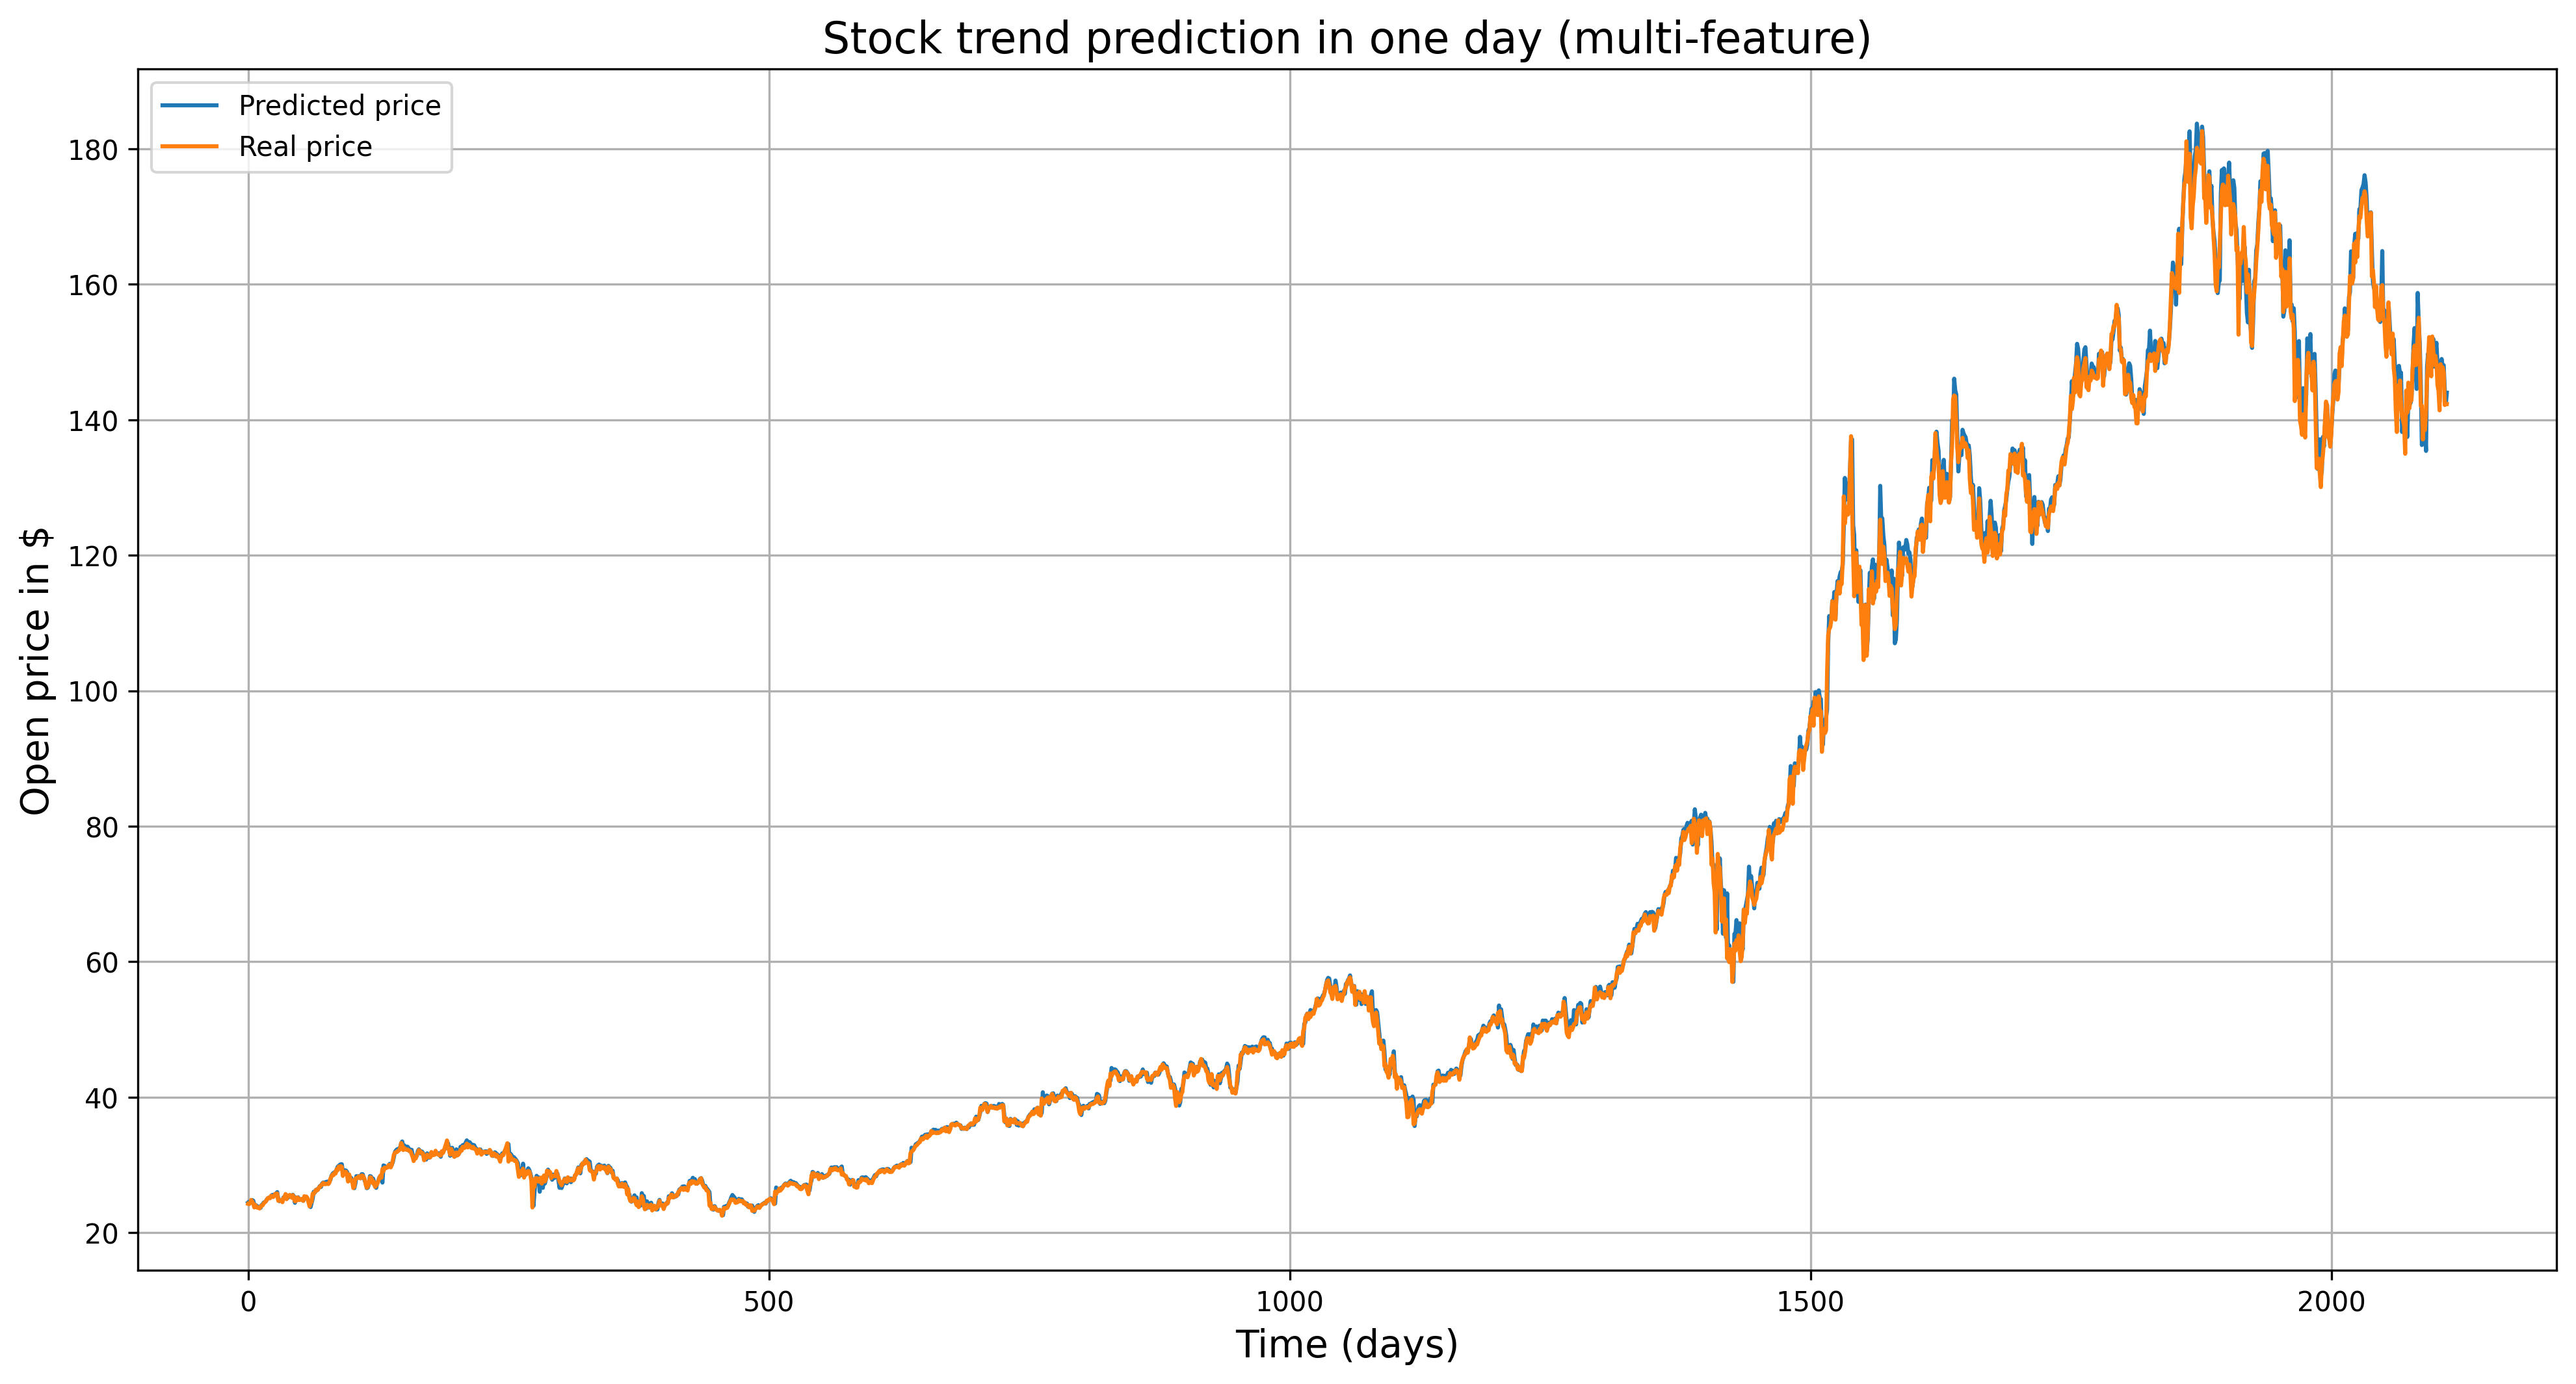

In [30]:
y_pred_denorm = y_pred_norm.copy()
for i in range(0, len(y_pred_denorm)):
    open_min = np.min(X_test[i, :, 1])
    open_max = np.max(X_test[i, :, 1])
    y_pred_denorm[i] = y_pred_norm[i] * (open_max - open_min) + open_min

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title('Stock trend prediction in one day (multi-feature)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Task 1.2: Nasdaq k-th Day Forecast

This section implements the k-th day forecast, predicting the stock price on the k-th day ahead instead of just the next day.

In [31]:
k_values = [1, 3, 5, 7]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Training model for k={k} day ahead prediction")
    print('='*50)
    
    results[k] = train_k(k) 
    print(f"MSE on test set (k={k}): {results[k]["mse_norm"]}")


Training model for k=1 day ahead prediction
Training set: 6756, Val: 1690, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6827 - mse: 0.6827 - val_loss: 0.1685 - val_mse: 0.1685
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1383 - mse: 0.1383 - val_loss: 0.1011 - val_mse: 0.1011
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0853 - mse: 0.0853 - val_loss: 0.0697 - val_mse: 0.0697
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0512 - mse: 0.0512 - val_loss: 0.0289 - val_mse: 0.0289
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0274 - mse: 0.0274 - val_loss: 0.0191 - val_mse: 0.0191
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step
MSE on test set (k=1): 0.02079937736012347

Training model for k=3 day ahead prediction
Training set: 6755, Val: 1689, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.0135 - mse: 2.0135 - val_loss: 0.2193 - val_mse: 0.2193
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1704 - mse: 0.1704 - val_loss: 0.1138 - val_mse: 0.1138
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1067 - mse: 0.1067 - val_loss: 0.0704 - val_mse: 0.0704
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0793 - mse: 0.0793 - val_loss: 0.0606 - val_mse: 0.0606
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0728 - mse: 0.0728 - val_loss: 0.0663 - val_mse: 0.0663
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step
MSE on test set (k=3): 0.07108648488229301

Training model for k=5 day ahead prediction
Training set: 6754, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.5911 - mse: 0.5911 - val_loss: 0.2669 - val_mse: 0.2669
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2519 - mse: 0.2519 - val_loss: 0.1684 - val_mse: 0.1684
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1630 - mse: 0.1630 - val_loss: 0.1177 - val_mse: 0.1177
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1380 - mse: 0.1380 - val_loss: 0.1128 - val_mse: 0.1128
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1347 - mse: 0.1347 - val_loss: 0.1102 - val_mse: 0.1102
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=5): 0.11207568287441706

Training model for k=7 day ahead prediction
Training set: 6752, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.6328 - mse: 1.6328 - val_loss: 0.3690 - val_mse: 0.3690
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3649 - mse: 0.3649 - val_loss: 0.2443 - val_mse: 0.2443
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2805 - mse: 0.2805 - val_loss: 0.2301 - val_mse: 0.2301
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2502 - mse: 0.2502 - val_loss: 0.1901 - val_mse: 0.1901
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2189 - mse: 0.2189 - val_loss: 0.1735 - val_mse: 0.1735
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=7): 0.17587981546101883


In [32]:
print("\n=== Task 1.2 Summary: k-th Day Forecast ===")
all_mse = [results[k]['mse_norm'] for k in k_values]
for k, mse in zip(k_values, all_mse):
    print(f"k={k}: MSE = {mse:.6f}")


=== Task 1.2 Summary: k-th Day Forecast ===
k=1: MSE = 0.020799
k=3: MSE = 0.071086
k=5: MSE = 0.112076
k=7: MSE = 0.175880


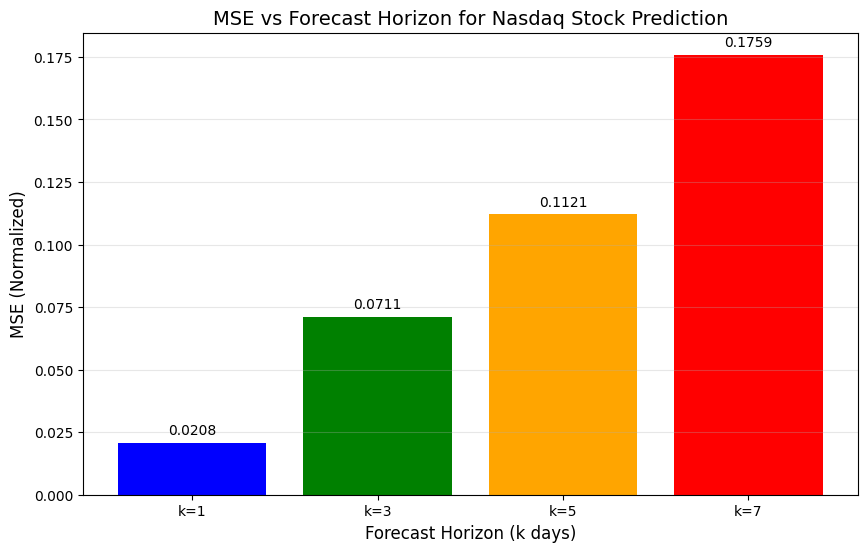

In [33]:
plt.figure(figsize=(10, 6))
bars = plt.bar([f'k={k}' for k in k_values], all_mse, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Forecast Horizon (k days)', fontsize=12)
plt.ylabel('MSE (Normalized)', fontsize=12)
plt.title('MSE vs Forecast Horizon for Nasdaq Stock Prediction', fontsize=14)
plt.grid(axis='y', alpha=0.3)
for bar, mse in zip(bars, all_mse):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{mse:.4f}', ha='center', va='bottom', fontsize=10)
plt.show()

## Task 1.3: Nasdaq k Days Forecast (Multi-Step)

This section implements predicting k consecutive days ahead in a single model. Unlike Task 1.2 which trains separate models for each forecast horizon, Task 1.3 trains one model to predict all k days simultaneously.


In [34]:
k_multistep = 7
print(f"\n{'='*50}")
print(f"Training multi-step model for k={k_multistep} consecutive days")
print('='*50)

X_multi, y_multi = prepare_data_multistep(df, feature_columns, window_size, k_multistep)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, shuffle=False)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_train_m, y_train_m, test_size=0.2, shuffle=False)

print(f"Training set: {X_train_m.shape[0]}, Val: {X_val_m.shape[0]}, Test: {X_test_m.shape[0]}")
print(f"Input shape: {X_train_m.shape}")
print(f"Output shape (k={k_multistep}): {y_train_m.shape}")

X_train_norm_m, y_train_norm_m = normalize_multifeature_multi(X_train_m, y_train_m, k_multistep)
X_val_norm_m, y_val_norm_m = normalize_multifeature_multi(X_val_m, y_val_m, k_multistep)
X_test_norm_m, y_test_norm_m = normalize_multifeature_multi(X_test_m, y_test_m, k_multistep)


Training multi-step model for k=7 consecutive days
Training set: 6752, Val: 1689, Test: 2111
Input shape: (6752, 30, 6)
Output shape (k=7): (6752, 7)


In [35]:
model_multi = tf.keras.Sequential()
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model_multi.add(MaxPooling1D(pool_size=2))
model_multi.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Flatten())
model_multi.add(Dense(100, activation='relu'))
model_multi.add(Dense(k_multistep))

model_multi.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_multi = model_multi.fit(X_train_norm_m, y_train_norm_m, validation_data=(X_val_norm_m, y_val_norm_m), epochs=5, batch_size=512, verbose=1)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.5970 - mse: 0.5970 - val_loss: 0.2500 - val_mse: 0.2500
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2076 - mse: 0.2076 - val_loss: 0.1461 - val_mse: 0.1461
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1322 - mse: 0.1322 - val_loss: 0.0935 - val_mse: 0.0935
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1081 - mse: 0.1081 - val_loss: 0.0890 - val_mse: 0.0890
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1033 - mse: 0.1033 - val_loss: 0.0864 - val_mse: 0.0864


In [36]:
y_pred_norm_m = model_multi.predict(X_test_norm_m)
mse_multi = mean_squared_error(y_pred_norm_m, y_test_norm_m)
print(f"\nOverall MSE (k={k_multistep} multi-step): {mse_multi}")

mse_per_day = []
for day in range(k_multistep):
    mse_day = mean_squared_error(y_pred_norm_m[:, day], y_test_norm_m[:, day])
    mse_per_day.append(mse_day)
    print(f"Day {day+1} MSE: {mse_day:.6f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Overall MSE (k=7 multi-step): 0.08852346531271313
Day 1 MSE: 0.016373
Day 2 MSE: 0.039741
Day 3 MSE: 0.064116
Day 4 MSE: 0.086630
Day 5 MSE: 0.112013
Day 6 MSE: 0.137730
Day 7 MSE: 0.163061


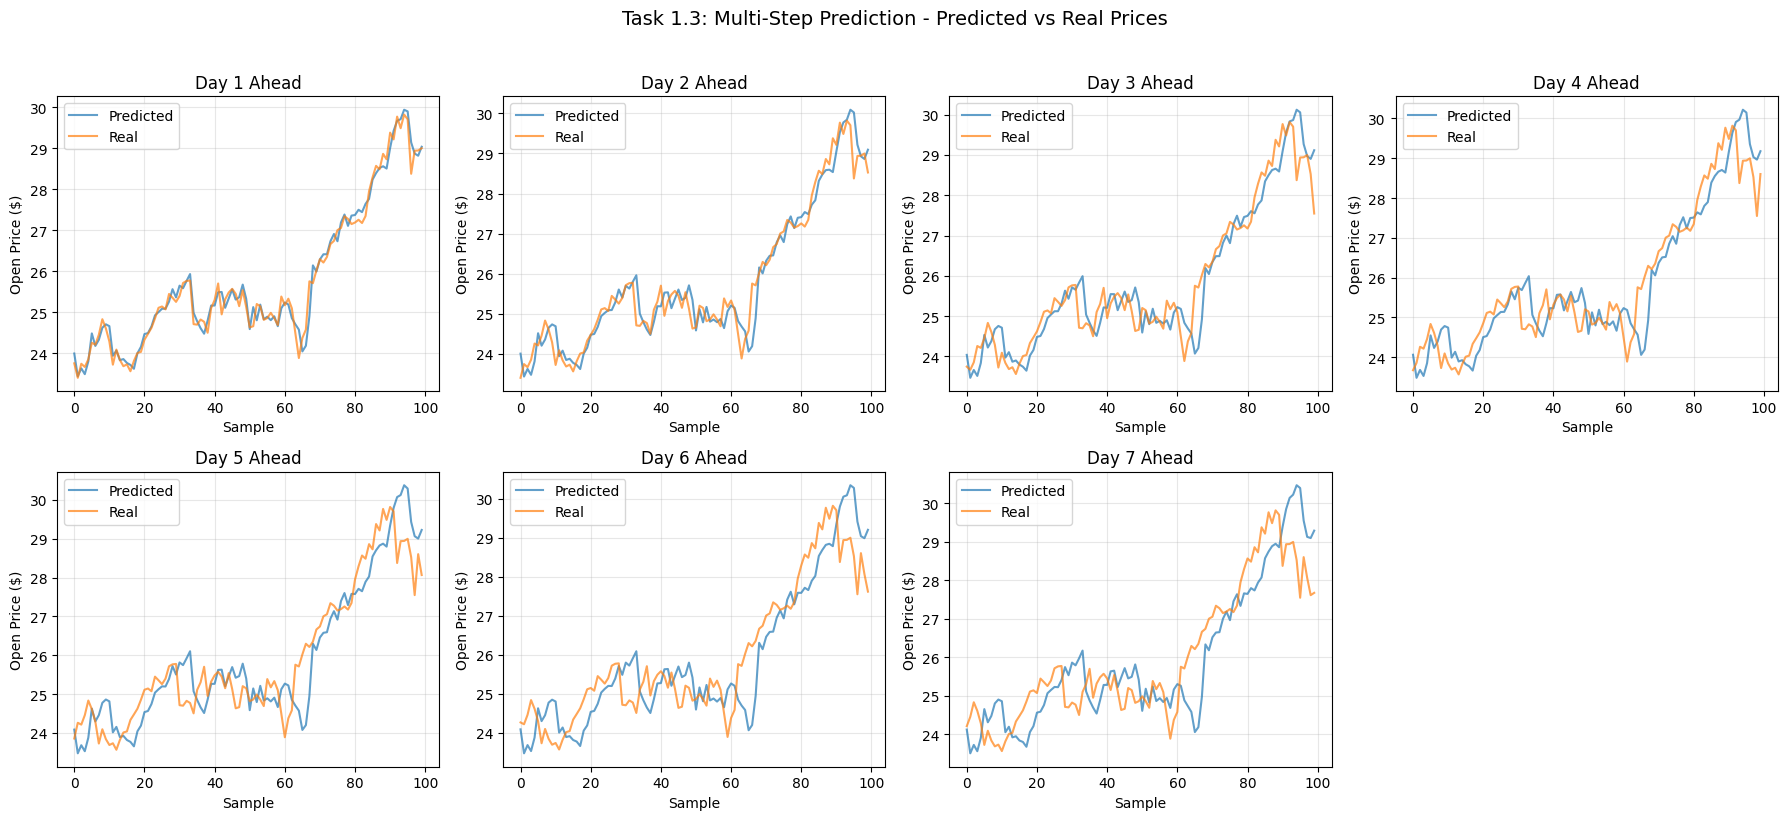

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for day in range(k_multistep):
    y_pred_denorm_day = y_pred_norm_m[:, day].copy()
    y_test_denorm_day = y_test_m[:, day].copy()
    
    for i in range(len(y_pred_denorm_day)):
        open_min = np.min(X_test_m[i, :, 1])
        open_max = np.max(X_test_m[i, :, 1])
        y_pred_denorm_day[i] = y_pred_norm_m[i, day] * (open_max - open_min) + open_min
    
    n_samples = min(100, len(y_pred_denorm_day))
    axes[day].plot(y_pred_denorm_day[:n_samples], label='Predicted', alpha=0.7)
    axes[day].plot(y_test_denorm_day[:n_samples], label='Real', alpha=0.7)
    axes[day].set_title(f'Day {day+1} Ahead')
    axes[day].set_xlabel('Sample')
    axes[day].set_ylabel('Open Price ($)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[7].axis('off')

plt.suptitle('Task 1.3: Multi-Step Prediction - Predicted vs Real Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 2.1: Vietnam Multi-Feature Extension

In [9]:
data_vn = pd.read_csv('./data/ACB-VNINDEX-History.csv')

In [10]:
data_vn.head()

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,5050.0,8234.0,6532.0,7147.0,56500,2006-11-21
1,1,6038.0,7861.0,7136.0,7394.0,62300,2006-11-22
2,2,6093.0,7959.0,7136.0,7597.0,69900,2006-11-23
3,3,5928.0,8344.0,7685.0,8058.0,63600,2006-11-24
4,4,6203.0,8860.0,7410.0,8058.0,42400,2006-11-27


In [11]:
data_vn.info()

<class 'pandas.DataFrame'>
RangeIndex: 4052 entries, 0 to 4051
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4052 non-null   int64  
 1   Open         4052 non-null   float64
 2   High         4052 non-null   float64
 3   Low          4052 non-null   float64
 4   Close        4052 non-null   float64
 5   Volume       4052 non-null   int64  
 6   TradingDate  4052 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 261.3 KB


In [12]:
data_vn = data_vn.rename(columns={'TradingDate': 'Date'})
df_vn = data_vn.copy()
feature_columns_vn = ['Low', 'Open', 'Volume', 'High', 'Close']
num_features_vn = len(feature_columns_vn)

X_data_vn = []
y_data_vn = []
window_size_vn = 30

for i in range(1, len(df_vn) - window_size_vn - 1):
    data_feature = []
    data_label = []
    
    for j in range(window_size_vn):
        data_feature.append(df_vn[feature_columns_vn].iloc[i + j].values)
    
    data_label = df_vn['Open'].iloc[i + window_size_vn]
    
    X_data_vn.append(np.array(data_feature))
    y_data_vn.append(np.array(data_label))

In [13]:
X_train_vn, X_test_vn, y_train_vn, y_test_vn = train_test_split(X_data_vn, y_data_vn, test_size=0.2, shuffle=False)
X_train_vn, X_val_vn, y_train_vn, y_val_vn = train_test_split(X_train_vn, y_train_vn, test_size=0.2, shuffle=False)

X_train_vn = np.array(X_train_vn)
X_val_vn = np.array(X_val_vn)
X_test_vn = np.array(X_test_vn)
y_train_vn = np.array(y_train_vn)
y_val_vn = np.array(y_val_vn)
y_test_vn = np.array(y_test_vn)

print("Shape of training set:", X_train_vn.shape)
print("Shape of validation set:", X_val_vn.shape)
print("Shape of test set:", X_test_vn.shape)
print("Number of features:", X_train_vn.shape[2])

Shape of training set: (2572, 30, 5)
Shape of validation set: (644, 30, 5)
Shape of test set: (804, 30, 5)
Number of features: 5


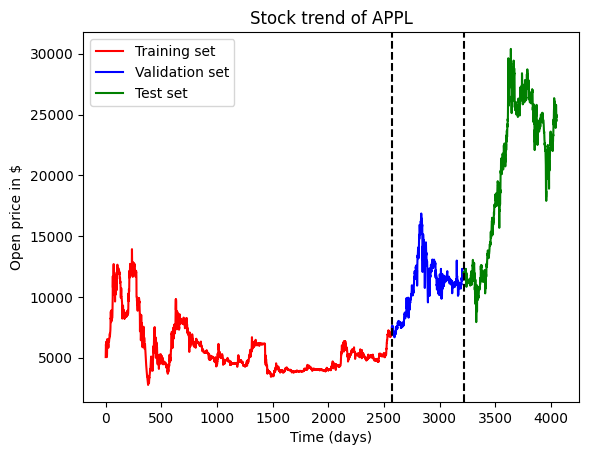

In [14]:
df_plot_vn = df_vn['Open']
df_plot_vn = df_plot_vn.reset_index(drop=False)

size_train_vn = X_train_vn.shape[0]
size_val_vn = X_val_vn.shape[0]
size_test_vn = X_test_vn.shape[0]

ax = df_plot_vn.iloc[:size_train_vn,1:2].plot(y=0, color='red', label='Training set')
df_plot_vn.iloc[size_train_vn:size_train_vn+size_val_vn,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot_vn.iloc[size_train_vn+size_val_vn:df_plot_vn.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train_vn, color='black', linestyle='--')
plt.axvline(x=size_train_vn+size_val_vn, color='black', linestyle='--')
plt.show()

In [15]:
X_train_norm_vn, y_train_norm_vn = normalize_multifeature(X_train_vn, y_train_vn)
X_val_norm_vn, y_val_norm_vn = normalize_multifeature(X_val_vn, y_val_vn)

In [16]:
model_vn = tf.keras.Sequential()
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
model_vn.add(MaxPooling1D(pool_size=2))
model_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Flatten())
model_vn.add(Dense(100, activation='relu'))
model_vn.add(Dense(1))

model_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_vn = model_vn.fit(X_train_norm_vn, y_train_norm_vn, validation_data=(X_val_norm_vn, y_val_norm_vn), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778486867.223359   61527 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778486867.223596   62595 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778486867.239886   61527 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned ab

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 4.2822 - mse: 4.2822 - val_loss: 0.4239 - val_mse: 0.4239
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2647 - mse: 0.2647 - val_loss: 0.1417 - val_mse: 0.1417
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2106 - mse: 0.2106 - val_loss: 0.2061 - val_mse: 0.2061
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1918 - mse: 0.1918 - val_loss: 0.1230 - val_mse: 0.1230
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1853 - mse: 0.1853 - val_loss: 0.2229 - val_mse: 0.2229


In [17]:
X_test_norm_vn, y_test_norm_vn = normalize_multifeature(X_test_vn, y_test_vn)
y_pred_norm_vn = model_vn.predict(X_test_norm_vn)
mse_vn = mean_squared_error(y_pred_norm_vn, y_test_norm_vn)
print(f"MSE on the Vietnam test set: {mse_vn}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE on the Vietnam test set: 0.2198751006490596


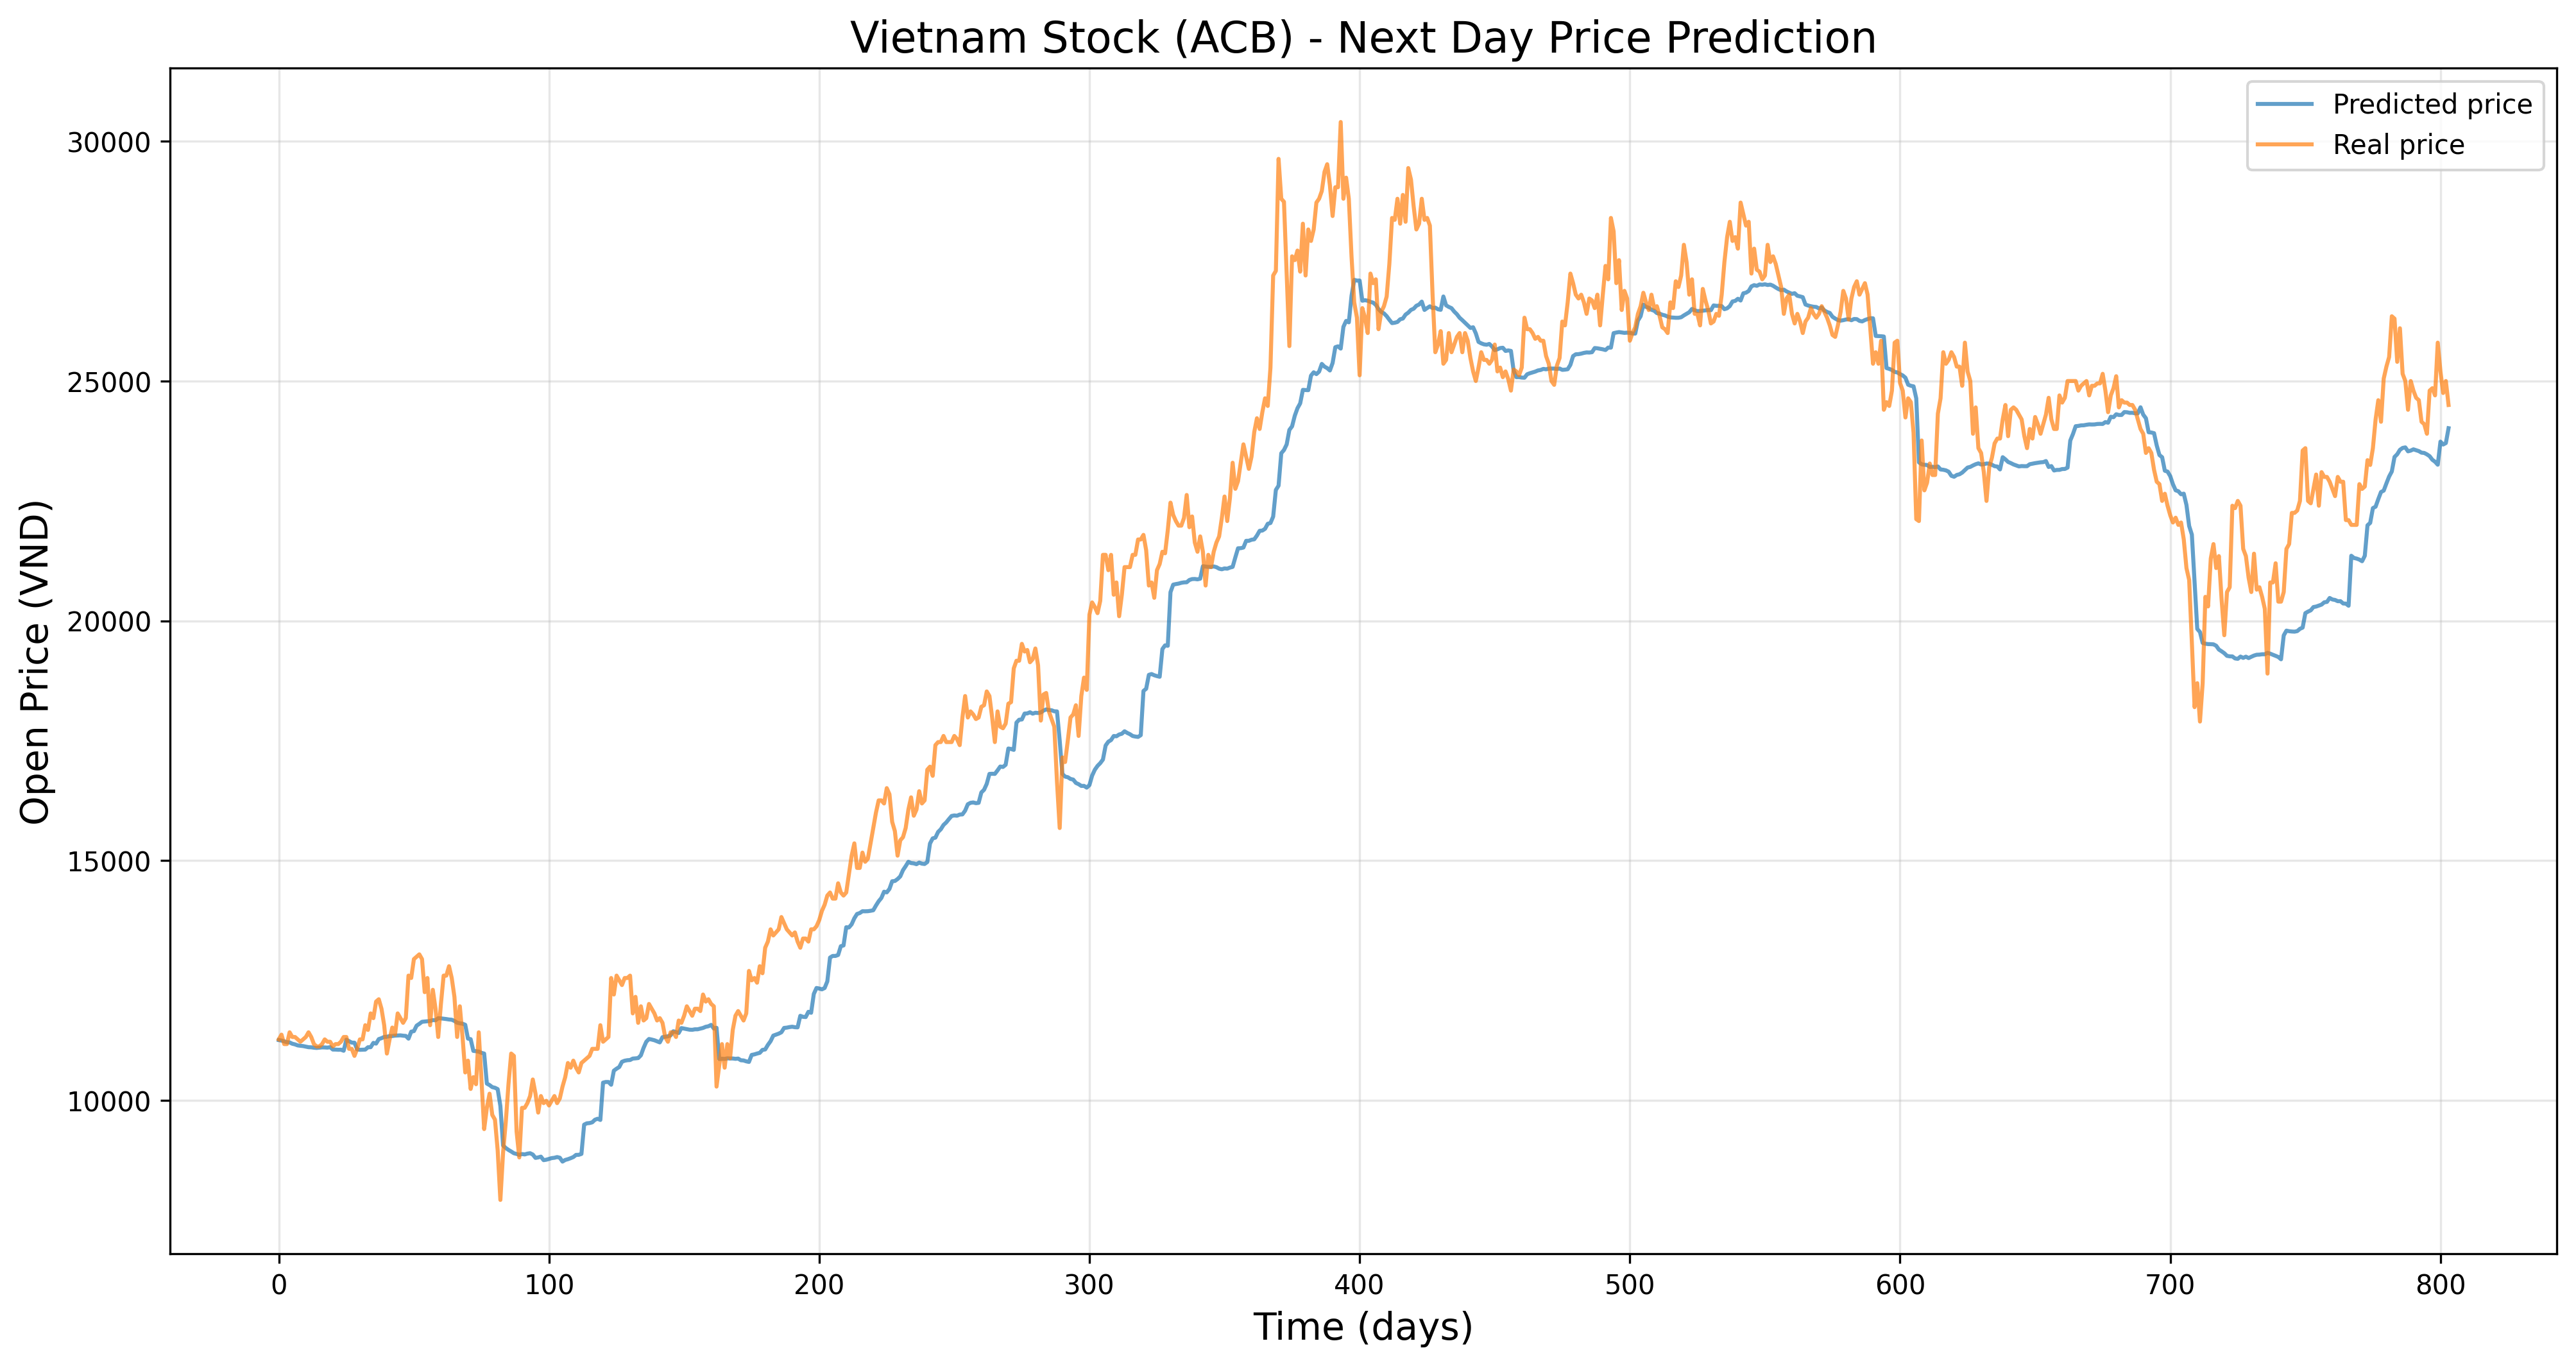

In [18]:
y_pred_denorm_vn = y_pred_norm_vn.copy()
for i in range(len(y_pred_denorm_vn)):
    open_min = np.min(X_test_vn[i, :, 1])
    open_max = np.max(X_test_vn[i, :, 1])
    y_pred_denorm_vn[i] = y_pred_norm_vn[i] * (open_max - open_min) + open_min

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_vn, label='Predicted price', alpha=0.7)
plt.plot(y_test_vn, label='Real price', alpha=0.7)
plt.title('Vietnam Stock (ACB) - Next Day Price Prediction', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open Price (VND)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Task 2.1 vs Task 1.1 Comparison

In [38]:
print(f"Task 1.1 (AAPL) MSE: {mse:.6f}")
print(f"Task 2.1 (ACB Vietnam) MSE: {mse_vn:.6f}")


Task 1.1 (AAPL) MSE: 0.175880
Task 2.1 (ACB Vietnam) MSE: 0.219875


MSE is higher for Vietnam market due to different market characteristics and less data normalization.

## Task 2.2: Vietnam k-th Day Forecast

This section implements forecasting Vietnam stock prices on the k-th day ahead (3rd, 5th, 7th day). Using the same approach as Task 1.2 but applied to the Vietnam market (ACB stock).


In [39]:
results_vn = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Training model for k={k} day ahead prediction")
    print('='*50)
    
    results_vn[k] = train_k(k) 
    print(f"MSE on test set (k={k}): {results_vn[k]["mse_norm"]}")


Training model for k=1 day ahead prediction
Training set: 6756, Val: 1690, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.1474 - mse: 1.1474 - val_loss: 0.1437 - val_mse: 0.1437
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1586 - mse: 0.1586 - val_loss: 0.1223 - val_mse: 0.1223
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1009 - mse: 0.1009 - val_loss: 0.0272 - val_mse: 0.0272
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0240 - mse: 0.0240 - val_loss: 0.0197 - val_mse: 0.0197
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0159 - mse: 0.0159 - val_loss: 0.0150 - val_mse: 0.0150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step
MSE on test set (k=1): 0.01559958022617596

Training model for k=3 day ahead prediction
Training set: 6755, Val: 1689, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.1717 - mse: 1.1717 - val_loss: 0.2138 - val_mse: 0.2138
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2001 - mse: 0.2001 - val_loss: 0.1136 - val_mse: 0.1136
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1038 - mse: 0.1038 - val_loss: 0.0700 - val_mse: 0.0700
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0782 - mse: 0.0782 - val_loss: 0.0612 - val_mse: 0.0612
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0729 - mse: 0.0729 - val_loss: 0.0587 - val_mse: 0.0587
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
MSE on test set (k=3): 0.06312630471959972

Training model for k=5 day ahead prediction
Training set: 6754, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.8714 - mse: 0.8714 - val_loss: 0.2900 - val_mse: 0.2900
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2692 - mse: 0.2692 - val_loss: 0.1920 - val_mse: 0.1920
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1991 - mse: 0.1991 - val_loss: 0.1466 - val_mse: 0.1466
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1598 - mse: 0.1598 - val_loss: 0.1253 - val_mse: 0.1253
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1399 - mse: 0.1399 - val_loss: 0.1179 - val_mse: 0.1179
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=5): 0.11874879786666026

Training model for k=7 day ahead prediction
Training set: 6752, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.3378 - mse: 1.3378 - val_loss: 0.3666 - val_mse: 0.3666
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3620 - mse: 0.3620 - val_loss: 0.2868 - val_mse: 0.2868
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3122 - mse: 0.3122 - val_loss: 0.2480 - val_mse: 0.2480
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2880 - mse: 0.2880 - val_loss: 0.2648 - val_mse: 0.2648
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2804 - mse: 0.2804 - val_loss: 0.2429 - val_mse: 0.2429
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=7): 0.24090086949815895


In [40]:
print("\n=== Task 2.2 Summary: Vietnam k-th Day Forecast ===")
all_mse_vn = [results_vn[k]['mse_norm'] for k in k_values]
for k, mse in zip(k_values, all_mse_vn):
    print(f"k={k}: MSE = {mse:.6f}")


=== Task 2.2 Summary: Vietnam k-th Day Forecast ===
k=1: MSE = 0.015600
k=3: MSE = 0.063126
k=5: MSE = 0.118749
k=7: MSE = 0.240901


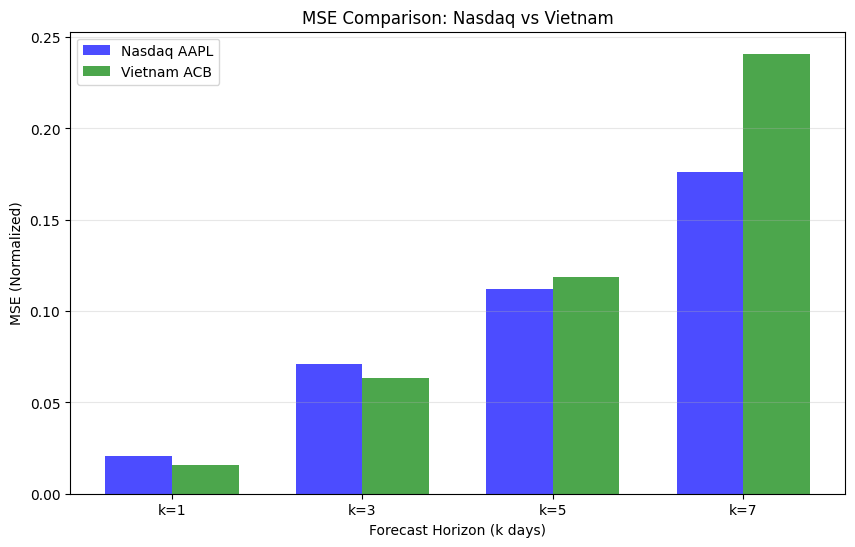

In [41]:
plt.figure(figsize=(10, 6))
x = np.arange(len(k_values))
width = 0.35

plt.bar(x - width/2, all_mse, width, label='Nasdaq AAPL', color='blue', alpha=0.7)
plt.bar(x + width/2, all_mse_vn, width, label='Vietnam ACB', color='green', alpha=0.7)
plt.xlabel('Forecast Horizon (k days)')
plt.ylabel('MSE (Normalized)')
plt.xticks(x, [f'k={k}' for k in k_values])
plt.title('MSE Comparison: Nasdaq vs Vietnam')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


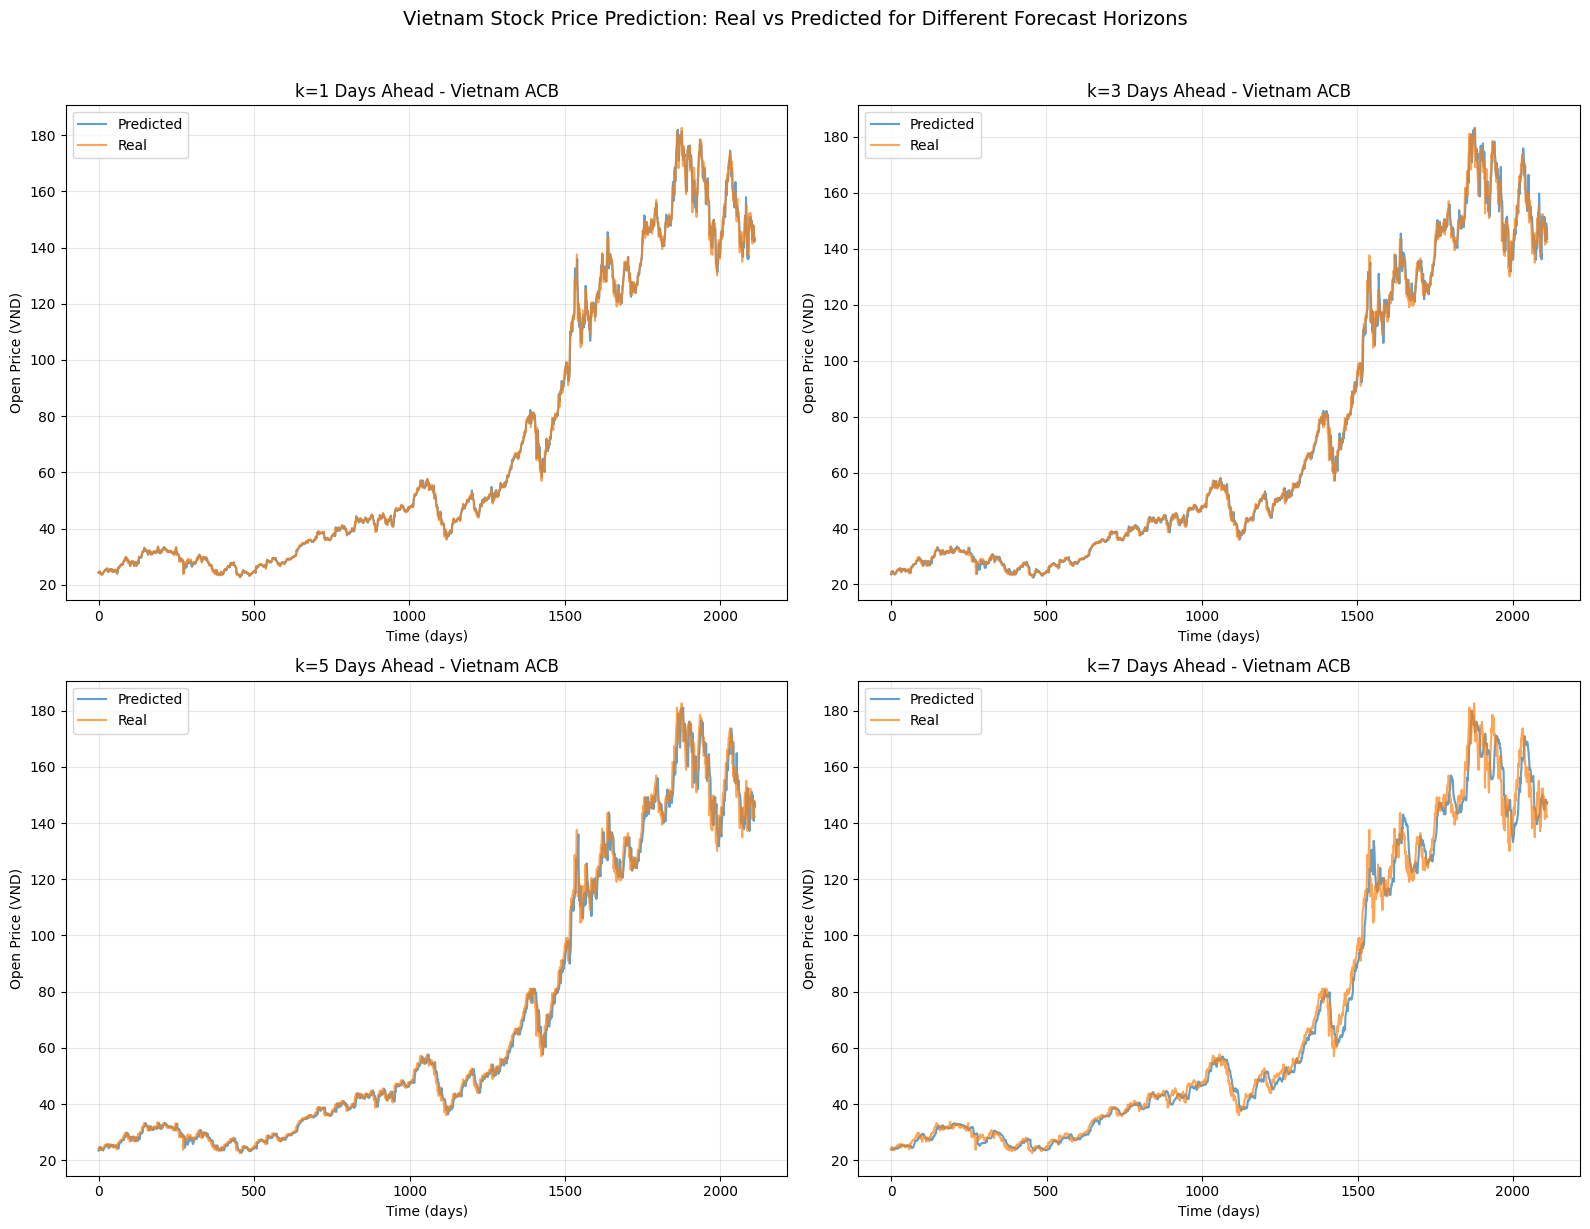

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, k in enumerate(k_values):
    row = idx // 2
    col = idx % 2
    axes[row, col].plot(results_vn[k]['y_pred_denorm'], label='Predicted', alpha=0.7)
    axes[row, col].plot(results_vn[k]['y_test'], label='Real', alpha=0.7)
    axes[row, col].set_title(f'k={k} Days Ahead - Vietnam ACB', fontsize=12)
    axes[row, col].set_xlabel('Time (days)')
    axes[row, col].set_ylabel('Open Price (VND)')
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.suptitle('Vietnam Stock Price Prediction: Real vs Predicted for Different Forecast Horizons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Task 2.3: Vietnam k Days Forecast (Multi-Step)

In [48]:
print(f"Training multi-step model for k={k_multistep} consecutive days (Vietnam)")

X_multi_vn, y_multi_vn = prepare_data_multistep(df_vn, feature_columns_vn, window_size_vn, k_multistep)

X_train_mv, X_test_mv, y_train_mv, y_test_mv = train_test_split(X_multi_vn, y_multi_vn, test_size=0.2, shuffle=False)
X_train_mv, X_val_mv, y_train_mv, y_val_mv = train_test_split(X_train_mv, y_train_mv, test_size=0.2, shuffle=False)

print(f"Training: {X_train_mv.shape[0]}, Val: {X_val_mv.shape[0]}, Test: {X_test_mv.shape[0]}")
print(f"Output shape (k={k_multistep}): {y_train_mv.shape}")

X_train_norm_mv, y_train_norm_mv = normalize_multifeature_multi(X_train_mv, y_train_mv, k_multistep)
X_val_norm_mv, y_val_norm_mv = normalize_multifeature_multi(X_val_mv, y_val_mv, k_multistep)
X_test_norm_mv, y_test_norm_mv = normalize_multifeature_multi(X_test_mv, y_test_mv, k_multistep)

Training multi-step model for k=7 consecutive days (Vietnam)
Training: 2568, Val: 643, Test: 803
Output shape (k=7): (2568, 7)


In [50]:
model_multi_vn = tf.keras.Sequential()
model_multi_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
model_multi_vn.add(MaxPooling1D(pool_size=2))
model_multi_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_multi_vn.add(MaxPooling1D(2))
model_multi_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_multi_vn.add(MaxPooling1D(2))
model_multi_vn.add(Flatten())
model_multi_vn.add(Dense(100, activation='relu'))
model_multi_vn.add(Dense(k_multistep))

model_multi_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_multi_vn = model_multi_vn.fit(X_train_norm_mv, y_train_norm_mv, validation_data=(X_val_norm_mv, y_val_norm_mv), epochs=5, batch_size=512, verbose=1)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.0053 - mse: 1.0053 - val_loss: 0.3152 - val_mse: 0.3152
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7098 - mse: 0.7098 - val_loss: 0.3394 - val_mse: 0.3394
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6850 - mse: 0.6850 - val_loss: 0.2270 - val_mse: 0.2270
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6649 - mse: 0.6649 - val_loss: 0.2111 - val_mse: 0.2111
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6360 - mse: 0.6360 - val_loss: 0.2050 - val_mse: 0.2050


In [54]:
y_pred_norm_mv = model_multi_vn.predict(X_test_norm_mv)
mse_multi_vn = mean_squared_error(y_pred_norm_mv, y_test_norm_mv)
print(f"Overall MSE (k={k_multistep}): {mse_multi_vn}")

mse_per_day_vn = []
for day in range(k_multistep):
    mse_day = mean_squared_error(y_pred_norm_mv[:, day], y_test_norm_mv[:, day])
    mse_per_day_vn.append(mse_day)
    print(f"Day {day+1} MSE: {mse_day:.6f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Overall MSE (k=7): 0.21650551868313178
Day 1 MSE: 0.128967
Day 2 MSE: 0.130728
Day 3 MSE: 0.185062
Day 4 MSE: 0.238963
Day 5 MSE: 0.238557
Day 6 MSE: 0.281990
Day 7 MSE: 0.311272


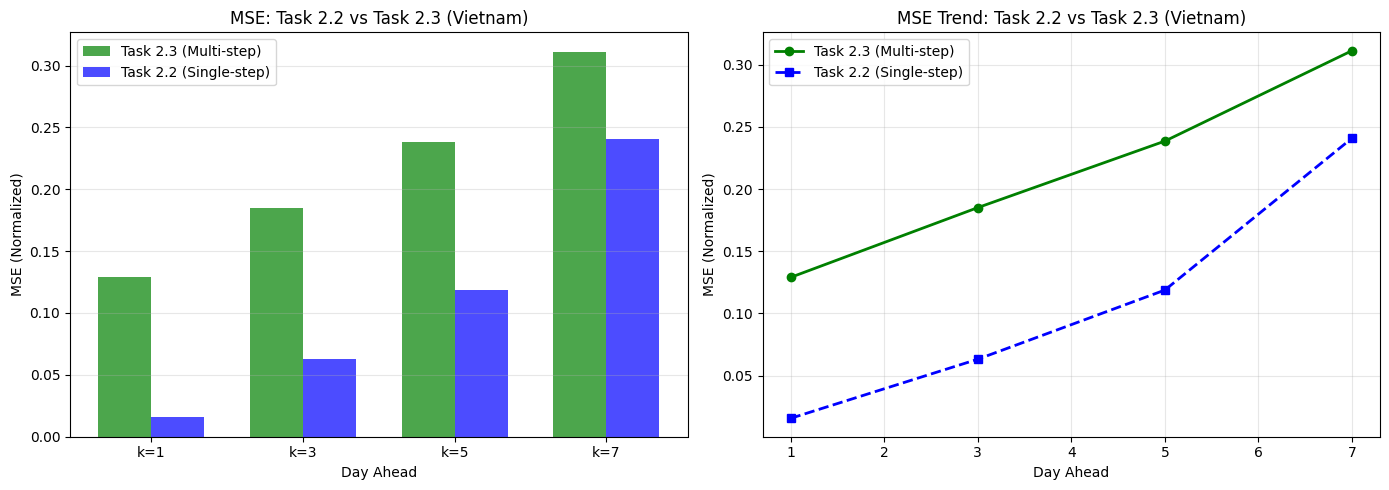

In [53]:
task_23_mse_matched = [mse_per_day_vn[0], mse_per_day_vn[2], mse_per_day_vn[4], mse_per_day_vn[6]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(4)
width = 0.35

axes[0].bar(x - width/2, task_23_mse_matched, width, label='Task 2.3 (Multi-step)', color='green', alpha=0.7)
axes[0].bar(x + width/2, all_mse_vn, width, label='Task 2.2 (Single-step)', color='blue', alpha=0.7)
axes[0].set_xlabel('Day Ahead')
axes[0].set_ylabel('MSE (Normalized)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['k=1', 'k=3', 'k=5', 'k=7'])
axes[0].set_title('MSE: Task 2.2 vs Task 2.3 (Vietnam)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(k_values, task_23_mse_matched, 'o-', label='Task 2.3 (Multi-step)', color='green', linewidth=2)
axes[1].plot(k_values, all_mse_vn, 's--', label='Task 2.2 (Single-step)', color='blue', linewidth=2)
axes[1].set_xlabel('Day Ahead')
axes[1].set_ylabel('MSE (Normalized)')
axes[1].set_title('MSE Trend: Task 2.2 vs Task 2.3 (Vietnam)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
print(f"Task 2.2 Avg MSE: {np.mean(all_mse):.6f}")
print(f"Task 2.3 (matched) Avg MSE: {np.mean(task_23_mse_matched):.6f}")

Task 2.2 Avg MSE: 0.094960
Task 2.3 (matched) Avg MSE: 0.215964


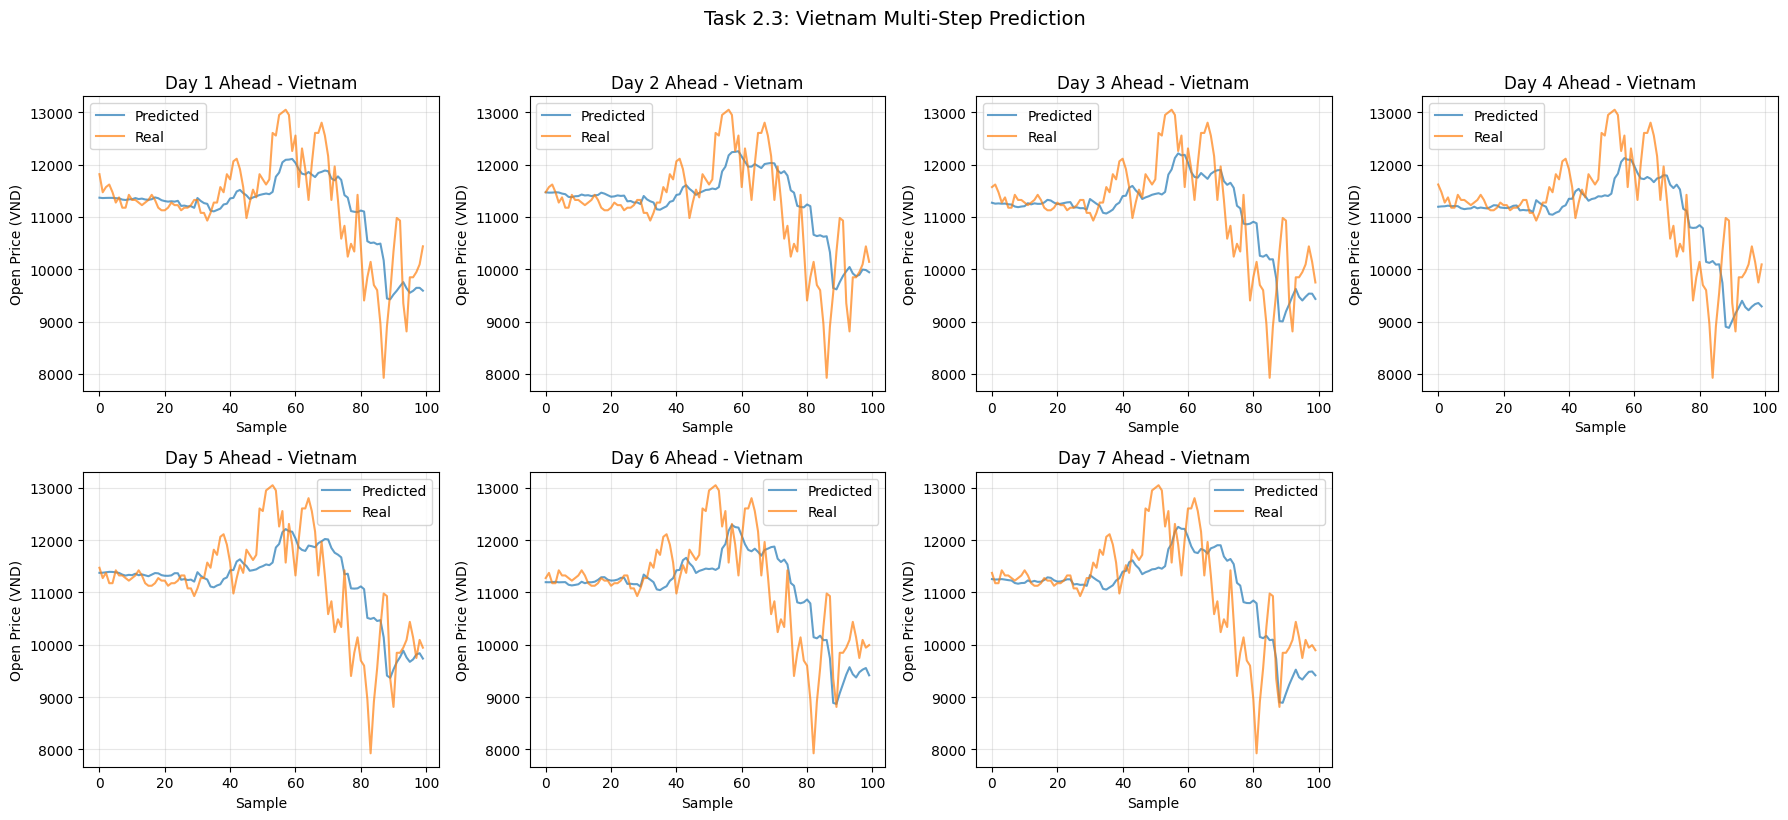

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for day in range(k_multistep):
    y_pred_denorm_day = y_pred_norm_mv[:, day].copy()
    y_test_denorm_day = y_test_mv[:, day].copy()
    
    for i in range(len(y_pred_denorm_day)):
        open_min = np.min(X_test_mv[i, :, 1])
        open_max = np.max(X_test_mv[i, :, 1])
        y_pred_denorm_day[i] = y_pred_norm_mv[i, day] * (open_max - open_min) + open_min
    
    n_samples = min(100, len(y_pred_denorm_day))
    axes[day].plot(y_pred_denorm_day[:n_samples], label='Predicted', alpha=0.7)
    axes[day].plot(y_test_denorm_day[:n_samples], label='Real', alpha=0.7)
    axes[day].set_title(f'Day {day+1} Ahead - Vietnam')
    axes[day].set_xlabel('Sample')
    axes[day].set_ylabel('Open Price (VND)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[7].axis('off')

plt.suptitle('Task 2.3: Vietnam Multi-Step Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 3.1: Buying Signal Identification

In [60]:
def compute_technical_indicators(df):
    df_tech = df.copy()
    
    df_tech['SMA_5'] = df['Close'].rolling(window=5).mean()
    df_tech['SMA_10'] = df['Close'].rolling(window=10).mean()
    df_tech['SMA_20'] = df['Close'].rolling(window=20).mean()
    
    df_tech['Price_SMA5_Ratio'] = df['Close'] / df_tech['SMA_5']
    df_tech['Price_SMA10_Ratio'] = df['Close'] / df_tech['SMA_10']
    df_tech['Price_SMA20_Ratio'] = df['Close'] / df_tech['SMA_20']
    
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = (-delta).where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df_tech['RSI'] = 100 - (100 / (1 + rs))
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df_tech['MACD'] = ema_12 - ema_26
    df_tech['MACD_Signal'] = df_tech['MACD'].ewm(span=9, adjust=False).mean()
    df_tech['MACD_Hist'] = df_tech['MACD'] - df_tech['MACD_Signal']
    
    df_tech['Volume_SMA'] = df['Volume'].rolling(window=10).mean()
    df_tech['Volume_Ratio'] = df['Volume'] / df_tech['Volume_SMA']
    
    df_tech['Return_1d'] = df['Close'].pct_change(1)
    df_tech['Return_5d'] = df['Close'].pct_change(5)
    df_tech['Return_10d'] = df['Close'].pct_change(10)
    
    return df_tech

In [61]:
def create_buy_labels(df, threshold=0.05, holding_period=10):
    future_return = df['Close'].shift(-holding_period) / df['Close'] - 1
    buy_signal = (future_return > threshold).astype(int)
    return buy_signal

In [62]:
df_tech = compute_technical_indicators(df_vn)
buy_labels = create_buy_labels(df_tech, threshold=0.05, holding_period=10)

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
             'Price_SMA5_Ratio', 'Price_SMA10_Ratio', 'Price_SMA20_Ratio',
             'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
             'Volume_Ratio', 'Return_1d', 'Return_5d', 'Return_10d']

df_tech = df_tech.dropna()
buy_labels = buy_labels.loc[df_tech.index].dropna()
common_idx = df_tech.index.intersection(buy_labels.index)
df_tech = df_tech.loc[common_idx]
buy_labels = buy_labels.loc[common_idx]

print("Samples:", len(df_tech))
print("Buy signals:", buy_labels.sum(), "(", (buy_labels.sum()/len(buy_labels))*100, "%)")

Samples: 4033
Buy signals: 759 ( 18.819737168361023 %)


In [63]:
window_size_cls = 30
num_features_cls = len(feature_cols)

X_buy = []
y_buy = []

for i in range(len(df_tech) - window_size_cls):
    window_data = df_tech[feature_cols].iloc[i:i + window_size_cls].values
    label = buy_labels.iloc[i + window_size_cls]
    X_buy.append(window_data)
    y_buy.append(label)

X_buy = np.array(X_buy)
y_buy = np.array(y_buy)

print("X shape:", X_buy.shape)
print("y shape:", y_buy.shape)
print("Class: Buy=", (y_buy==1).sum(), ", NoBuy=", (y_buy==0).sum())

X shape: (4003, 30, 16)
y shape: (4003,)
Class: Buy= 736 , NoBuy= 3267


In [64]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_buy, y_buy, test_size=0.2, shuffle=False)
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X_train_b, y_train_b, test_size=0.2, shuffle=False)

X_train_b = np.array(X_train_b)
X_val_b = np.array(X_val_b)
X_test_b = np.array(X_test_b)
y_train_b = np.array(y_train_b)
y_val_b = np.array(y_val_b)
y_test_b = np.array(y_test_b)

print("Train:", X_train_b.shape[0], "Val:", X_val_b.shape[0], "Test:", X_test_b.shape[0])

Train: 2561 Val: 641 Test: 801


In [65]:
def normalize_classification(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            X_norm[i, :, f] = (X[i, :, f] - min_val) / denom if denom != 0 else 0
    return X_norm, y_norm

In [66]:
X_train_norm_b, y_train_norm_b = normalize_classification(X_train_b, y_train_b)
X_val_norm_b, y_val_norm_b = normalize_classification(X_val_b, y_val_b)
X_test_norm_b, y_test_norm_b = normalize_classification(X_test_b, y_test_b)

In [67]:
model_buy = tf.keras.Sequential()
model_buy.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_cls, num_features_cls), padding='same'))
model_buy.add(MaxPooling1D(pool_size=2))
model_buy.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_buy.add(MaxPooling1D(2))
model_buy.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_buy.add(MaxPooling1D(2))
model_buy.add(Flatten())
model_buy.add(Dense(100, activation='relu'))
model_buy.add(Dropout(0.3))
model_buy.add(Dense(1, activation='sigmoid'))

model_buy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
history_buy = model_buy.fit(X_train_norm_b, y_train_norm_b, validation_data=(X_val_norm_b, y_val_norm_b), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7747 - loss: 0.6640 - val_accuracy: 0.7816 - val_loss: 0.5279
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8508 - loss: 0.4374 - val_accuracy: 0.7816 - val_loss: 0.5311
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8508 - loss: 0.5124 - val_accuracy: 0.7816 - val_loss: 0.5366
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8508 - loss: 0.4495 - val_accuracy: 0.7816 - val_loss: 0.6956
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8508 - loss: 0.4435 - val_accuracy: 0.7816 - val_loss: 0.5268


In [68]:
y_pred_b = model_buy.predict(X_test_norm_b)
y_pred_class = (y_pred_b > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test_b, y_pred_class)
precision = precision_score(y_test_b, y_pred_class, zero_division=0)
recall = recall_score(y_test_b, y_pred_class, zero_division=0)
cm = confusion_matrix(y_test_b, y_pred_class)

print("=== Buy Signal Results ===")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Buy Signal Results ===
Accuracy: 0.7328339575530587
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[587   0]
 [214   0]]


In [69]:
random.seed(42)
y_random = np.array([random.randint(0, 1) for _ in range(len(y_test_b))])

random_acc = accuracy_score(y_test_b, y_random)

print("=== Comparison ===")
print("Random:", random_acc)
print("Model:", accuracy)
print("Improvement:", ((accuracy - random_acc) / random_acc * 100), "%")

=== Comparison ===
Random: 0.49812734082397003
Model: 0.7328339575530587
Improvement: 47.117794486215544 %


## Task 3.2: Selling Signal Identification

This section implements a model to identify potential exit points for selling Vietnam stocks. Inverse of Task 3.1, we identify when to sell based on negative momentum or approaching profit targets.


In [70]:
def create_sell_labels(df, threshold=-0.05, holding_period=10):
    future_return = df['Close'].shift(-holding_period) / df['Close'] - 1
    sell_signal = (future_return < threshold).astype(int)
    return sell_signal

In [71]:
sell_labels = create_sell_labels(df_tech, threshold=-0.05, holding_period=10)
sell_labels = sell_labels.loc[df_tech.index].dropna()
common_idx = df_tech.index.intersection(sell_labels.index)
sell_labels = sell_labels.loc[common_idx]

print("Total samples:", len(sell_labels))
print("Sell signals:", sell_labels.sum(), "(", (sell_labels.sum()/len(sell_labels))*100, "%)")
print("No Sell:", (sell_labels==0).sum())

Total samples: 4033
Sell signals: 610 ( 15.125216960079346 %)
No Sell: 3423


In [72]:
X_sell = []
y_sell = []

for i in range(len(df_tech) - window_size_cls):
    window_data = df_tech[feature_cols].iloc[i:i + window_size_cls].values
    label = sell_labels.iloc[i + window_size_cls]
    X_sell.append(window_data)
    y_sell.append(label)

X_sell = np.array(X_sell)
y_sell = np.array(y_sell)

print("X shape:", X_sell.shape)
print("y shape:", y_sell.shape)
print("Class: Sell=", (y_sell==1).sum(), ", NoSell=", (y_sell==0).sum())

X shape: (4003, 30, 16)
y shape: (4003,)
Class: Sell= 610 , NoSell= 3393


In [73]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sell, y_sell, test_size=0.2, shuffle=False)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(X_train_s, y_train_s, test_size=0.2, shuffle=False)

X_train_s = np.array(X_train_s)
X_val_s = np.array(X_val_s)
X_test_s = np.array(X_test_s)
y_train_s = np.array(y_train_s)
y_val_s = np.array(y_val_s)
y_test_s = np.array(y_test_s)

print("Train:", X_train_s.shape[0], "Val:", X_val_s.shape[0], "Test:", X_test_s.shape[0])

Train: 2561 Val: 641 Test: 801


In [74]:
X_train_norm_s, y_train_norm_s = normalize_classification(X_train_s, y_train_s)
X_val_norm_s, y_val_norm_s = normalize_classification(X_val_s, y_val_s)
X_test_norm_s, y_test_norm_s = normalize_classification(X_test_s, y_test_s)

In [75]:
model_sell = tf.keras.Sequential()
model_sell.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_cls, num_features_cls), padding='same'))
model_sell.add(MaxPooling1D(pool_size=2))
model_sell.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_sell.add(MaxPooling1D(2))
model_sell.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_sell.add(MaxPooling1D(2))
model_sell.add(Flatten())
model_sell.add(Dense(100, activation='relu'))
model_sell.add(Dropout(0.3))
model_sell.add(Dense(1, activation='sigmoid'))

model_sell.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
history_sell = model_sell.fit(X_train_norm_s, y_train_norm_s, validation_data=(X_val_norm_s, y_val_norm_s), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7708 - loss: 0.6611 - val_accuracy: 0.8690 - val_loss: 0.3989
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8403 - loss: 0.4711 - val_accuracy: 0.8690 - val_loss: 0.4132
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8403 - loss: 0.4529 - val_accuracy: 0.8690 - val_loss: 0.4044
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8403 - loss: 0.4649 - val_accuracy: 0.8690 - val_loss: 0.4071
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8403 - loss: 0.4480 - val_accuracy: 0.8690 - val_loss: 0.3956


In [76]:
y_pred_s = model_sell.predict(X_test_norm_s)
y_pred_class_s = (y_pred_s > 0.5).astype(int).flatten()

accuracy_s = accuracy_score(y_test_s, y_pred_class_s)
precision_s = precision_score(y_test_s, y_pred_class_s, zero_division=0)
recall_s = recall_score(y_test_s, y_pred_class_s, zero_division=0)
cm_s = confusion_matrix(y_test_s, y_pred_class_s)

print("=== Sell Signal Results ===")
print("Accuracy:", accuracy_s)
print("Precision:", precision_s)
print("Recall:", recall_s)
print("Confusion Matrix:", cm_s)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Sell Signal Results ===
Accuracy: 0.8539325842696629
Precision: 0.0
Recall: 0.0
Confusion Matrix: [[684   0]
 [117   0]]


### Task 3.1 vs Task 3.2 Comparison

In [77]:
print("Buy Signal (Task 3.1) Accuracy:", accuracy)
print("Sell Signal (Task 3.2) Accuracy:", accuracy_s)

Buy Signal (Task 3.1) Accuracy: 0.7328339575530587
Sell Signal (Task 3.2) Accuracy: 0.8539325842696629


Both models use technical indicators to identify trading opportunities

## Task 4.1: Profitable Stock Selection

This section selects profitable Vietnamese companies for portfolio inclusion. We analyze historical performance and predict future returns to rank companies by profit potential.


In [78]:
companies_df = pd.read_csv(f'data/companies.csv')

In [79]:
companies_df.head()

,Unnamed: 0,ticker,group_code,company_name,company_short_name
0,0,VVS,UpcomIndex,Công ty Cổ phần Đầu tư Phát triển Máy Việt Nam,Đầu tư Phát triển Máy Việt Nam
1,1,XDC,UpcomIndex,Công ty TNHH MTV Xây dựng Công trình Tân Cảng,Xây dựng Công trình Tân Cảng
2,2,HSV,UpcomIndex,Công ty Cổ phần Gang Thép Hà Nội,Gang Thép Hà Nội
3,3,CST,UpcomIndex,Công ty Cổ phần Than Cao Sơn - TKV,Than Cao Sơn - TKV
4,4,BVL,UpcomIndex,Công ty Cổ phần BV Land,BV Land


In [80]:
companies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          1629 non-null   int64
 1   ticker              1629 non-null   str  
 2   group_code          1629 non-null   str  
 3   company_name        1629 non-null   str  
 4   company_short_name  1629 non-null   str  
dtypes: int64(1), str(4)
memory usage: 200.5 KB


In [81]:
tickers = []
stock_dir = f'data/stock-historical-data'

for f in os.listdir(stock_dir):
    if f.endswith('-History.csv'):
        ticker = f.replace('-History.csv', '')
        tickers.append(ticker)

print("Total tickers found:", len(tickers))
print("Sample tickers:", tickers[:10])

Total tickers found: 1629
Sample tickers: ['A32-UpcomIndex', 'AAA-VNINDEX', 'AAM-VNINDEX', 'AAS-UpcomIndex', 'AAT-VNINDEX', 'AAV-HNXIndex', 'ABB-UpcomIndex', 'ABC-UpcomIndex', 'ABI-UpcomIndex', 'ABR-VNINDEX']


In [82]:
def analyze_stock(ticker):
    try:
        df = pd.read_csv(f'{stock_dir}/{ticker}-History.csv')
        if len(df) < 120:
            return None
        
        returns_30d = (df['Close'].iloc[-1] / df['Close'].iloc[-30] - 1) if len(df) >= 30 else 0
        returns_60d = (df['Close'].iloc[-1] / df['Close'].iloc[-60] - 1) if len(df) >= 60 else 0
        returns_90d = (df['Close'].iloc[-1] / df['Close'].iloc[-90] - 1) if len(df) >= 90 else 0
        
        volatility = df['Close'].pct_change().std() * np.sqrt(252)
        
        avg_volume = df['Volume'].mean()
        
        return {
            'ticker': ticker,
            'returns_30d': returns_30d,
            'returns_60d': returns_60d,
            'returns_90d': returns_90d,
            'volatility': volatility,
            'avg_volume': avg_volume,
            'data_points': len(df)
        }
    except:
        return None

In [83]:
results = []
for ticker in tickers:
    result = analyze_stock(ticker)
    if result:
        results.append(result)

results_df = pd.DataFrame(results)
print(f"Analyzed {len(results_df)} companies with >=120 data points")

/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027:

Analyzed 1613 companies with >=120 data points


In [84]:
results_df = results_df.sort_values('returns_90d', ascending=False)

top_10 = results_df.head(10)
print("=== Top 10 Most Profitable Companies (90-day returns) ===")
print(top_10[['ticker', 'returns_90d', 'returns_60d', 'returns_30d', 'volatility']])

=== Top 10 Most Profitable Companies (90-day returns) ===
              ticker  returns_90d  returns_60d  returns_30d  volatility
66    BMV-UpcomIndex     2.140940     1.250000     0.608247    0.482047
542   HFB-UpcomIndex     2.035294     2.394737    -0.030075    0.852779
1359    TSB-HNXIndex     1.991304     2.822222     0.051988    0.470211
538   HEM-UpcomIndex     1.568000     1.791304    -0.024316    0.877636
806   MLC-UpcomIndex     1.555556     1.555556    -0.190141    0.280839
706   KSK-UpcomIndex     1.545455     0.400000    -0.034483    1.236556
1008    PRC-HNXIndex     1.447917     0.620690     0.492063    0.480162
345   DNT-UpcomIndex     1.346809     0.959147     0.399746    0.597781
276   CTW-UpcomIndex     1.293233     0.138060     0.229839    0.762294
381   DTN-UpcomIndex     1.222615     1.222615    -0.150000    0.651141


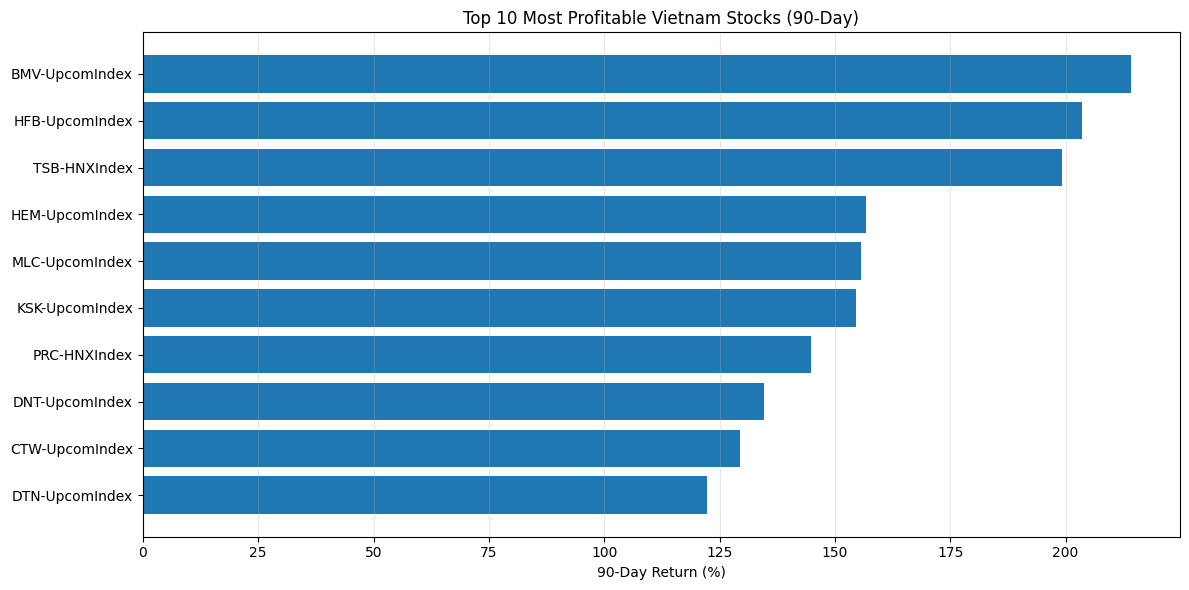

In [85]:
plt.figure(figsize=(12, 6))
top_10_plot = top_10.sort_values('returns_90d')
plt.barh(top_10_plot['ticker'], top_10_plot['returns_90d'] * 100)
plt.xlabel('90-Day Return (%)')
plt.title('Top 10 Most Profitable Vietnam Stocks (90-Day)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
top_10['projected_profit'] = top_10['returns_90d'] * 100
top_10['risk_score'] = top_10['volatility'] * 100
top_10['liquidity_score'] = top_10['avg_volume'] / top_10['avg_volume'].max() * 100

print("=== Task 4.1: Selected Profitable Companies ===")
for idx, row in top_10.iterrows():
    print(f"{row['ticker']}: Return={row['projected_profit']:.1f}%, Risk={row['risk_score']:.1f}%, Liquidity={row['liquidity_score']:.1f}%")

=== Task 4.1: Selected Profitable Companies ===
BMV-UpcomIndex: Return=214.1%, Risk=48.2%, Liquidity=0.0%
HFB-UpcomIndex: Return=203.5%, Risk=85.3%, Liquidity=0.3%
TSB-HNXIndex: Return=199.1%, Risk=47.0%, Liquidity=0.9%
HEM-UpcomIndex: Return=156.8%, Risk=87.8%, Liquidity=0.8%
MLC-UpcomIndex: Return=155.6%, Risk=28.1%, Liquidity=0.0%
KSK-UpcomIndex: Return=154.5%, Risk=123.7%, Liquidity=100.0%
PRC-HNXIndex: Return=144.8%, Risk=48.0%, Liquidity=0.3%
DNT-UpcomIndex: Return=134.7%, Risk=59.8%, Liquidity=0.0%
CTW-UpcomIndex: Return=129.3%, Risk=76.2%, Liquidity=0.0%
DTN-UpcomIndex: Return=122.3%, Risk=65.1%, Liquidity=0.1%


In [87]:
portfolio = top_10.head(5)[['ticker', 'returns_90d', 'volatility']].copy()
portfolio['weight'] = portfolio['returns_90d'] / portfolio['returns_90d'].sum()
print("=== Recommended Portfolio (Top 5) ===")
print(portfolio)

expected_return = (portfolio['returns_90d'] * portfolio['weight']).sum()
print(f"\nExpected 90-day return: {expected_return*100:.1f}%")

=== Recommended Portfolio (Top 5) ===
              ticker  returns_90d  volatility    weight
66    BMV-UpcomIndex     2.140940    0.482047  0.230429
542   HFB-UpcomIndex     2.035294    0.852779  0.219059
1359    TSB-HNXIndex     1.991304    0.470211  0.214324
538   HEM-UpcomIndex     1.568000    0.877636  0.168764
806   MLC-UpcomIndex     1.555556    0.280839  0.167424

Expected 90-day return: 189.1%


## Task 4.2: Risk Management

In [88]:
def calculate_risk_metrics(ticker):
    try:
        df = pd.read_csv(f'{stock_dir}/{ticker}-History.csv')
        if len(df) < 120:
            return None
        
        returns = df['Close'].pct_change().dropna()
        volatility = returns.std() * np.sqrt(252)
        
        rolling_max = df['Close'].cummax()
        drawdown = (df['Close'] - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        
        avg_volume = df['Volume'].mean()
        
        momentum_90d = (df['Close'].iloc[-1] / df['Close'].iloc[-90] - 1) if len(df) >= 90 else 0
        
        return {
            'ticker': ticker,
            'volatility': volatility,
            'max_drawdown': max_drawdown,
            'avg_volume': avg_volume,
            'momentum_90d': momentum_90d,
            'data_points': len(df)
        }
    except:
        return None

In [89]:
risk_results = []
for ticker in tickers:
    result = calculate_risk_metrics(ticker)
    if result:
        risk_results.append(result)

risk_df = pd.DataFrame(risk_results)
print(f"Analyzed {len(risk_df)} companies")

/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027:

Analyzed 1613 companies


In [90]:
risk_df['vol_score'] = (risk_df['volatility'] - risk_df['volatility'].min()) / (risk_df['volatility'].max() - risk_df['volatility'].min())
risk_df['drawdown_score'] = (risk_df['max_drawdown'] - risk_df['max_drawdown'].max()) / (risk_df['max_drawdown'].min() - risk_df['max_drawdown'].max())
risk_df['liquidity_score'] = 1 - (risk_df['avg_volume'] - risk_df['avg_volume'].min()) / (risk_df['avg_volume'].max() - risk_df['avg_volume'].min())
risk_df['momentum_score'] = (risk_df['momentum_90d'] - risk_df['momentum_90d'].min()) / (risk_df['momentum_90d'].max() - risk_df['momentum_90d'].min())

risk_df['risk_score'] = (
    0.3 * risk_df['vol_score'] + 
    0.3 * risk_df['drawdown_score'] + 
    0.2 * risk_df['liquidity_score'] + 
    0.2 * risk_df['momentum_score']
)

print("Risk score calculated (0=low risk, 1=high risk)")

Risk score calculated (0=low risk, 1=high risk)


In [91]:
high_risk = risk_df[risk_df['risk_score'] > 0.7].sort_values('risk_score', ascending=False)
medium_risk = risk_df[(risk_df['risk_score'] > 0.4) & (risk_df['risk_score'] <= 0.7)].sort_values('risk_score', ascending=False)
low_risk = risk_df[risk_df['risk_score'] <= 0.4].sort_values('risk_score', ascending=True)

print("=== Risk Classification ===")
print(f"High Risk (>0.7): {len(high_risk)} companies")
print(f"Medium Risk (0.4-0.7): {len(medium_risk)} companies")
print(f"Low Risk (<0.4): {len(low_risk)} companies")

=== Risk Classification ===
High Risk (>0.7): 9 companies
Medium Risk (0.4-0.7): 1499 companies
Low Risk (<0.4): 75 companies


In [92]:
top_risky = high_risk.head(10)
print("=== Top 10 Highest Risk Companies ===")
print(top_risky[['ticker', 'risk_score', 'volatility', 'max_drawdown']])

=== Top 10 Highest Risk Companies ===
              ticker  risk_score  volatility  max_drawdown
791   MEF-UpcomIndex    0.858729    2.254377     -0.997059
706   KSK-UpcomIndex    0.819774    1.236556     -0.995050
966   PHS-UpcomIndex    0.792410    2.095497     -0.900505
1126    SD5-HNXIndex    0.782059    1.857270     -0.947297
542   HFB-UpcomIndex    0.720458    0.852779     -0.713043
1424  V15-UpcomIndex    0.718175    1.212432     -0.993283
824   MTG-UpcomIndex    0.712847    0.757259     -0.914821
847   NCS-UpcomIndex    0.707532    1.431916     -0.819222
1140  PXM-UpcomIndex    0.704500    1.120885     -0.988521


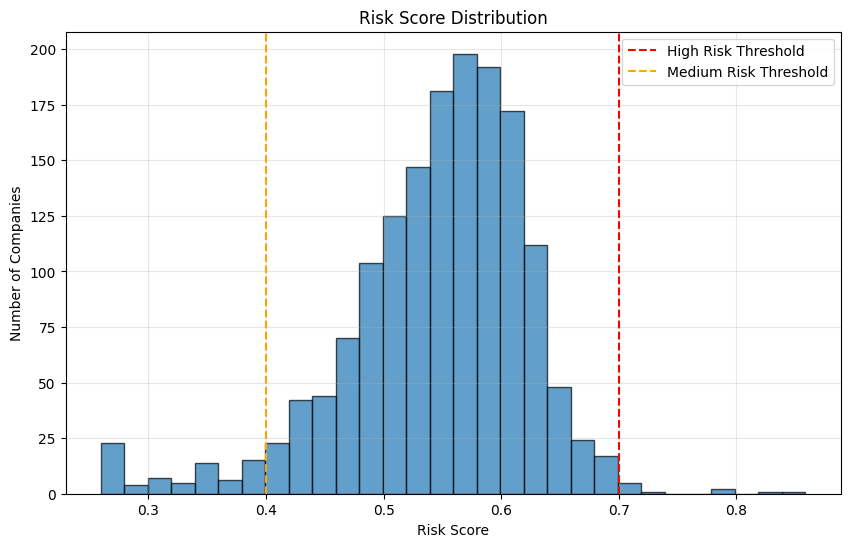

In [93]:
plt.figure(figsize=(10, 6))
plt.hist(risk_df['risk_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0.7, color='red', linestyle='--', label='High Risk Threshold')
plt.axvline(x=0.4, color='orange', linestyle='--', label='Medium Risk Threshold')
plt.xlabel('Risk Score')
plt.ylabel('Number of Companies')
plt.title('Risk Score Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [94]:
safe_stocks = results_df[~results_df['ticker'].isin(high_risk['ticker'])].copy()
safe_stocks = safe_stocks.merge(risk_df[['ticker', 'risk_score']], on='ticker', how='left')
safe_stocks = safe_stocks.sort_values('returns_90d', ascending=False)

print("=== Task 4.2: Safe Stocks After Risk Filtering ===")
print(f"Original: {len(results_df)} | After filtering: {len(safe_stocks)}")
print(f"\nTop 5 safe stocks:")
print(safe_stocks.head(5)[['ticker', 'returns_90d', 'risk_score']])

=== Task 4.2: Safe Stocks After Risk Filtering ===
Original: 1613 | After filtering: 1604

Top 5 safe stocks:
           ticker  returns_90d  risk_score
0  BMV-UpcomIndex     2.140940    0.655057
1    TSB-HNXIndex     1.991304    0.688067
2  HEM-UpcomIndex     1.568000    0.619511
3  MLC-UpcomIndex     1.555556    0.538864
4    PRC-HNXIndex     1.447917    0.664711


## Task 4.3: Portfolio Composition

This section combines profitability (Task 4.1) and risk management (Task 4.2) to design an optimal portfolio construction strategy with asset allocation.


In [95]:
portfolio_df = results_df.merge(risk_df[['ticker', 'risk_score']], on='ticker', how='inner')

portfolio_df = portfolio_df[portfolio_df['risk_score'] <= 0.7].copy()
portfolio_df = portfolio_df.sort_values('returns_90d', ascending=False)

top_n = 10
portfolio_df = portfolio_df.head(top_n)

print(f"=== Selected {top_n} Stocks for Portfolio ===")
print(portfolio_df[['ticker', 'returns_90d', 'risk_score']])

=== Selected 10 Stocks for Portfolio ===
            ticker  returns_90d  risk_score
0   BMV-UpcomIndex     2.140940    0.655057
2     TSB-HNXIndex     1.991304    0.688067
3   HEM-UpcomIndex     1.568000    0.619511
4   MLC-UpcomIndex     1.555556    0.538864
6     PRC-HNXIndex     1.447917    0.664711
7   DNT-UpcomIndex     1.346809    0.669782
8   CTW-UpcomIndex     1.293233    0.650598
9   DTN-UpcomIndex     1.222615    0.651430
10    INC-HNXIndex     1.206452    0.647817
12  KLM-UpcomIndex     1.190476    0.690474


In [96]:
portfolio_df['weight_equal'] = 1 / len(portfolio_df)

returns_total = portfolio_df['returns_90d'].sum()
portfolio_df['weight_momentum'] = portfolio_df['returns_90d'] / returns_total

portfolio_df['return_risk'] = portfolio_df['returns_90d'] / (portfolio_df['risk_score'] + 0.01)
return_risk_total = portfolio_df['return_risk'].sum()
portfolio_df['weight_risk_adj'] = portfolio_df['return_risk'] / return_risk_total

print("=== Portfolio Weights ===")
print(portfolio_df[['ticker', 'weight_equal', 'weight_momentum', 'weight_risk_adj']])

=== Portfolio Weights ===
            ticker  weight_equal  weight_momentum  weight_risk_adj
0   BMV-UpcomIndex           0.1         0.143079         0.140799
2     TSB-HNXIndex           0.1         0.133079         0.124766
3   HEM-UpcomIndex           0.1         0.104790         0.108943
4   MLC-UpcomIndex           0.1         0.103958         0.123958
6     PRC-HNXIndex           0.1         0.096765         0.093860
7   DNT-UpcomIndex           0.1         0.090007         0.086655
8   CTW-UpcomIndex           0.1         0.086427         0.085624
9   DTN-UpcomIndex           0.1         0.081708         0.080846
10    INC-HNXIndex           0.1         0.080627         0.080216
12  KLM-UpcomIndex           0.1         0.079560         0.074333


In [ ]:
expected_return_eq = (portfolio_df['returns_90d'] * portfolio_df['weight_equal']).sum()
expected_risk_eq = (portfolio_df['risk_score'] * portfolio_df['weight_equal']).sum()

expected_return_mom = (portfolio_df['returns_90d'] * portfolio_df['weight_momentum']).sum()
expected_risk_mom = (portfolio_df['risk_score'] * portfolio_df['weight_momentum']).sum()

expected_return_risk = (portfolio_df['returns_90d'] * portfolio_df['weight_risk_adj']).sum()
expected_risk_risk = (portfolio_df['risk_score'] * portfolio_df['weight_risk_adj']).sum()

sharpe_eq = expected_return_eq / (expected_risk_eq + 0.01)
sharpe_mom = expected_return_mom / (expected_risk_mom + 0.01)
sharpe_risk = expected_return_risk / (expected_risk_risk + 0.01)

print("=== Portfolio Performance Comparison ===")
print(f"Strategy             | Exp Return | Exp Risk | Sharpe")
print(f"Equal Weight       | {expected_return_eq*100:6.1f}%   | {expected_risk_eq:.2f}   | {sharpe_eq:.2f}")
print(f"Momentum         | {expected_return_mom*100:6.1f}%   | {expected_risk_mom:.2f}   | {sharpe_mom:.2f}")
print(f"Risk-Adjusted     | {expected_return_risk*100:6.1f}%   | {expected_risk_risk:.2f}   | {sharpe_risk:.2f}")

=== Portfolio Performance Comparison ===
Strategy             | Exp Return | Exp Risk | Sharpe
Equal Weight       |  149.6%   | 0.65   | 2.28
Momentum         |  156.2%   | 0.65   | 2.38
Risk-Adjusted     |  156.1%   | 0.64   | 2.39


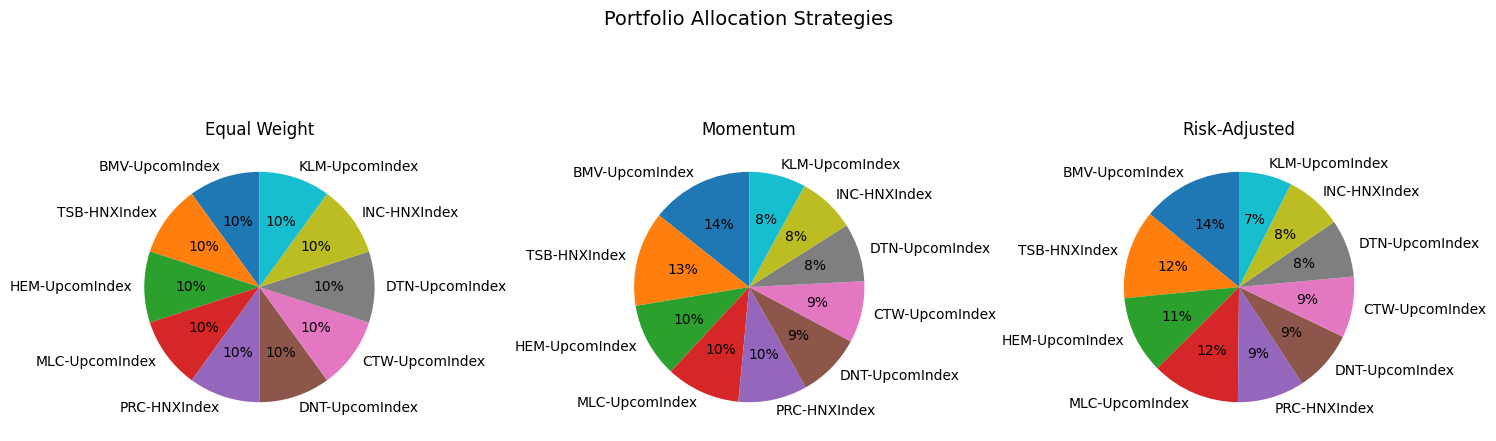

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(portfolio_df['weight_equal'], labels=portfolio_df['ticker'], autopct='%1.0f%%', startangle=90)
axes[0].set_title('Equal Weight')

axes[1].pie(portfolio_df['weight_momentum'], labels=portfolio_df['ticker'], autopct='%1.0f%%', startangle=90)
axes[1].set_title('Momentum')

axes[2].pie(portfolio_df['weight_risk_adj'], labels=portfolio_df['ticker'], autopct='%1.0f%%', startangle=90)
axes[2].set_title('Risk-Adjusted')

plt.suptitle('Portfolio Allocation Strategies', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Task 4.3: Final Portfolio Recommendation

Recommended Strategy: Risk-Adjusted

In [99]:
best_weights = portfolio_df['weight_risk_adj']

print(f"\nTop 5 Holdings:")
top_5 = portfolio_df.head(5)[['ticker', 'returns_90d', 'risk_score', 'weight_risk_adj']].copy()
top_5['weight_risk_adj'] = top_5['weight_risk_adj'] * 100
for idx, row in top_5.iterrows():
    print(f"  {row['ticker']}: {row['weight_risk_adj']:.1f}% (Return: {row['returns_90d']*100:.1f}%, Risk: {row['risk_score']:.2f})")

print(f"\nExpected Portfolio Return: {expected_return_risk*100:.1f}%")
print(f"Expected Portfolio Risk: {expected_risk_risk:.2f}")
print(f"Sharpe Ratio: {sharpe_risk:.2f}")



Top 5 Holdings:
  BMV-UpcomIndex: 14.1% (Return: 214.1%, Risk: 0.66)
  TSB-HNXIndex: 12.5% (Return: 199.1%, Risk: 0.69)
  HEM-UpcomIndex: 10.9% (Return: 156.8%, Risk: 0.62)
  MLC-UpcomIndex: 12.4% (Return: 155.6%, Risk: 0.54)
  PRC-HNXIndex: 9.4% (Return: 144.8%, Risk: 0.66)

Expected Portfolio Return: 156.1%
Expected Portfolio Risk: 0.64
Sharpe Ratio: 2.39
